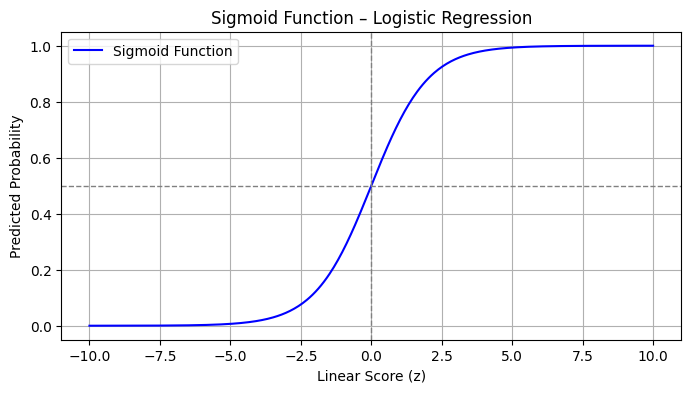

In [1]:
%reset -f
import numpy as np
import matplotlib.pyplot as plt

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Generate values for z
z = np.linspace(-10, 10, 400)
prob = sigmoid(z)

# Plot
plt.figure(figsize=(8, 4))
plt.plot(z, prob, label='Sigmoid Function', color='blue')
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1)
plt.title("Sigmoid Function – Logistic Regression")
plt.xlabel("Linear Score (z)")
plt.ylabel("Predicted Probability")
plt.grid(True)
plt.legend()
plt.show()


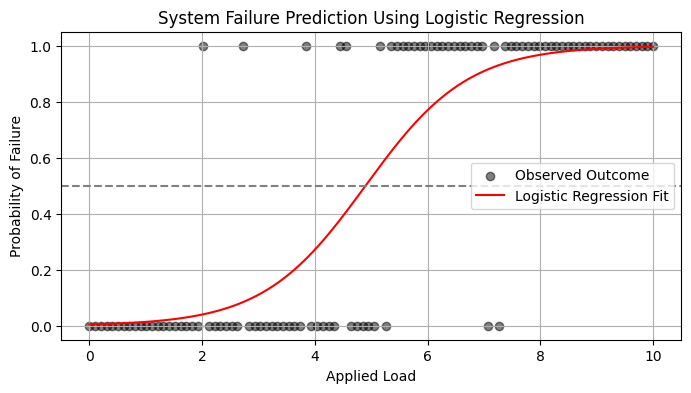

In [2]:
%reset -f
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Simulated data
np.random.seed(0)
load = np.linspace(0, 10, 100).reshape(-1, 1)
failure_prob = 1 / (1 + np.exp(-1.2 * (load - 5)))  # Centered around 5
failure = np.random.binomial(1, failure_prob.ravel())  # Simulate binary outcomes

# Fit logistic regression
model = LogisticRegression()
model.fit(load, failure)

# Predict probabilities
load_test = np.linspace(0, 10, 200).reshape(-1, 1)
predicted_prob = model.predict_proba(load_test)[:, 1]

# Plot
plt.figure(figsize=(8, 4))
plt.scatter(load, failure, label='Observed Outcome', alpha=0.5, color='black')
plt.plot(load_test, predicted_prob, label='Logistic Regression Fit', color='red')
plt.axhline(0.5, linestyle='--', color='gray')
plt.title("System Failure Prediction Using Logistic Regression")
plt.xlabel("Applied Load")
plt.ylabel("Probability of Failure")
plt.legend()
plt.grid(True)
plt.show()


In [3]:
%reset -f
# Load the data
experience=[14,29,6,25,18,4,18,12,22,6,30,11,30,5,20,13,9,32,24,13,19,4,28,22,8]
result=[0,0,0,1,1,0,0,0,1,0,1,0,1,0,1,0,0,1,0,1,0,0,1,1,1]

In [4]:
# Load a Plotting Tool
import matplotlib.pyplot as plt
def make1plot(listx1,listy1,strlablx,strlably,strtitle):
    mydata = plt.figure(figsize = (6,6)) # build a square drawing canvass from figure class
    plt.plot(listx1,listy1, c='red', marker='o',linewidth=0) # basic data plot
    plt.xlabel(strlablx)
    plt.ylabel(strlably)
    plt.legend(['Data','Model'])# modify for argument insertion
    plt.title(strtitle)
    plt.grid(axis='y')
    plt.show()
def make2plot(listx1,listy1,listx2,listy2,strlablx,strlably,strtitle):
    mydata = plt.figure(figsize = (6,6)) # build a square drawing canvass from figure class
    plt.plot(listx1,listy1, c='red', marker='o',linewidth=0) # basic data plot
    plt.plot(listx2,listy2, c='blue',linewidth=1) # basic model plot
    plt.xlabel(strlablx)
    plt.ylabel(strlably)
    plt.legend(['Data','Model'])# modify for argument insertion
    plt.title(strtitle)
    plt.grid(axis='y')
    plt.show()

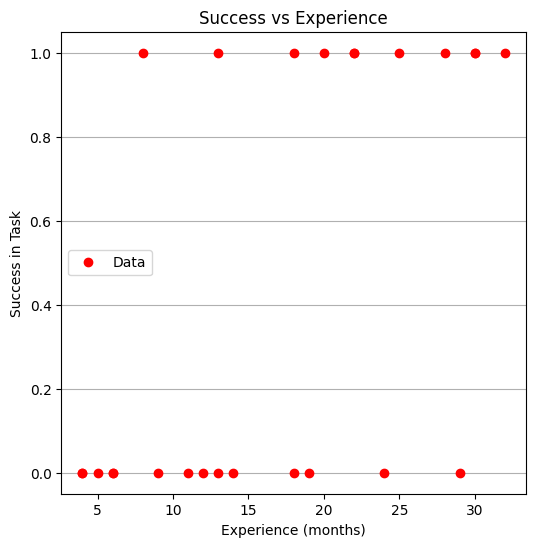

In [5]:
make1plot(experience,result,"Experience (months)","Success in Task","Success vs Experience")

In [6]:
def pii(b0,b1,x): #sigmoidal function
    import math
    pii = math.exp(b0+b1*x)/(1+ math.exp(b0+b1*x))
    return(pii)

def sse(mod,obs): #compute sse from observations and model values
    howmany = len(mod)
    sse=0.0
    for i in range(howmany):
        sse=sse+(mod[i]-obs[i])**2
    return(sse)

def merit(beta): # merit function to minimize
    global result,experience #access lists already defined external to function
    mod=[0 for i in range(len(experience))]
    for i in range(len(experience)):
        mod[i]=pii(beta[0],beta[1],experience[i])
    merit = sse(mod,result)
    return(merit)

In [7]:
beta = [0,0] #initial guess of betas
merit(beta) #check that does not raise an exception

6.25

In [8]:
import numpy as np
from scipy.optimize import minimize

#x0 = np.array([-3.0597,0.1615])
x0 = np.array(beta)
res = minimize(merit, x0, method='powell',options={'disp': True})

Optimization terminated successfully.
         Current function value: 4.199713
         Iterations: 5
         Function evaluations: 132


 b0 =  -2.982390266878914
 b1 =  0.15954743797099522


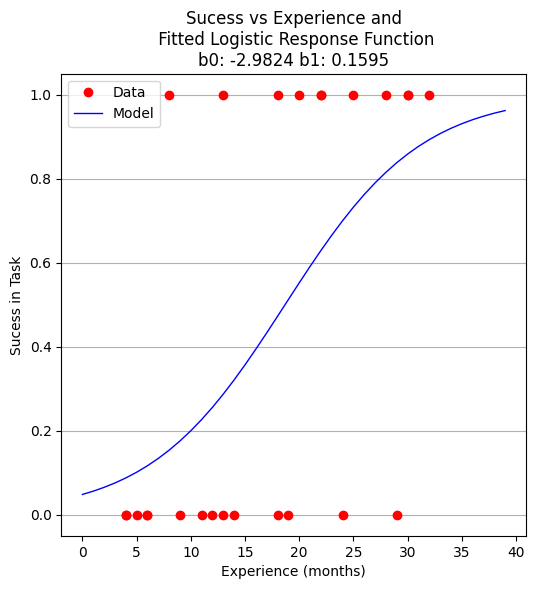

In [9]:
fitted=[0 for i in range(40)]
xaxis =[0 for i in range(40)]
beta[0]=res.x[0]
beta[1]=res.x[1]
for i in range(40):
    xaxis[i]=float(i)
    fitted[i]=pii(res.x[0],res.x[1],float(i))
    
print(" b0 = ",res.x[0])
print(" b1 = ",res.x[1])
plottitle = 'Sucess vs Experience and\n Fitted Logistic Response Function\n'+'b0: '+ str(round(res.x[0],4))+ ' b1: ' +str(round(res.x[1],4))
make2plot(experience,result,xaxis,fitted,'Experience (months)','Sucess in Task',plottitle)

In [10]:
guess = 25.5
pii(res.x[0],res.x[1],guess)

0.7476408418994896

In [11]:
guess = 18.75
pii(res.x[0],res.x[1],guess)

0.5022810329444896

In [12]:
# import the class
import numpy
from sklearn.linear_model import LogisticRegression
X = numpy.array(experience)
y = numpy.array(result)
# instantiate the model (using the default parameters)
logreg = LogisticRegression(solver='lbfgs',max_iter=10000);
# fit the model with data  -TRAIN the model
logreg.fit(X.reshape(-1, 1),y);

In [13]:
logreg.coef_

array([[0.16080665]])

In [14]:
xplot = numpy.array(xaxis)
y_pred=logreg.predict(xplot.reshape(-1,1))

b0 = logreg.intercept_[0]
b1 = logreg.coef_[0][0]



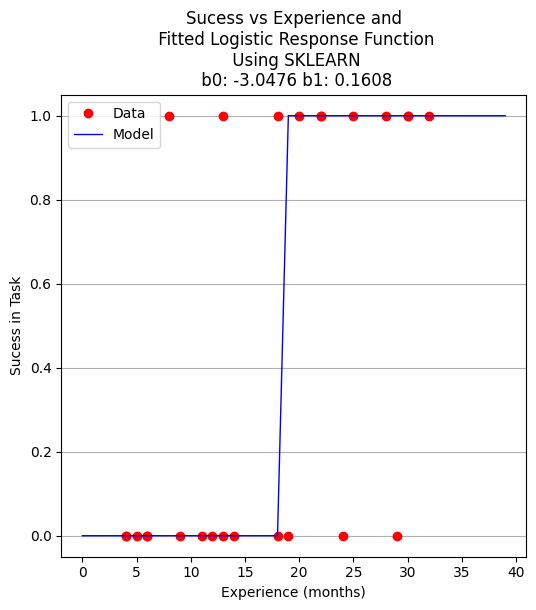

In [15]:
plottitle = 'Sucess vs Experience and\n Fitted Logistic Response Function\n Using SKLEARN\n '+'b0: '+ str(round(b0,4)) + ' b1: ' + str(round(b1,4))
make2plot(experience,result,xplot,y_pred,'Experience (months)','Sucess in Task',plottitle)

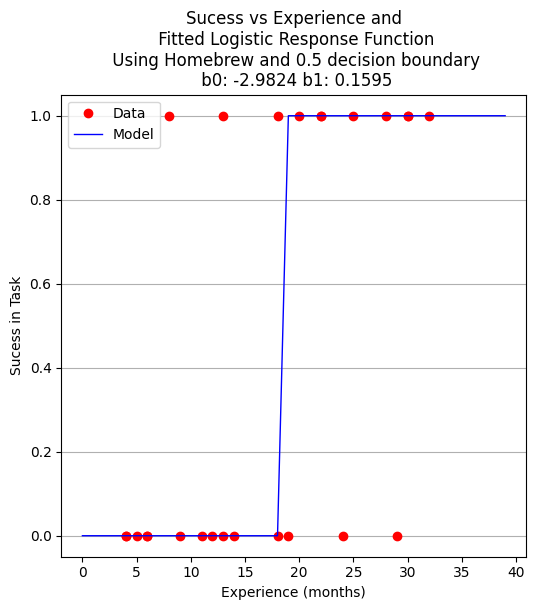

In [16]:
for i in range(40):
    xaxis[i]=float(i)
    fitted[i]=pii(beta[0],beta[1],float(i))
#    fitted[i]=pii(b0,b1,float(i))
    if fitted[i] > 0.5:
        fitted[i] = 1.0
    else:
        fitted[i]=0.0

plottitle = 'Sucess vs Experience and\n Fitted Logistic Response Function\n Using Homebrew and 0.5 decision boundary\n '+'b0: '+ str(round(beta[0],4)) + ' b1: ' + str(round(beta[1],4))
make2plot(experience,result,xaxis,fitted,'Experience (months)','Sucess in Task',plottitle)

In [17]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=0)

In [18]:
# instantiate the model (using the default parameters)
logreg = LogisticRegression(solver='lbfgs',max_iter=10000);
# fit the model with data  -TRAIN the model
logreg.fit(X_train.reshape(-1, 1),y_train);

In [19]:
xplot = numpy.array(xaxis)
y_pred=logreg.predict(X_test.reshape(-1,1))

b0 = logreg.intercept_[0]
b1 = logreg.coef_[0][0]

for i in range(40):
    xaxis[i]=float(i)
#    fitted[i]=pii(beta[0],beta[1],float(i))
    fitted[i]=pii(b0,b1,float(i))
    if fitted[i] > 0.5:
        fitted[i] = 1.0
    else:
        fitted[i]=0.0

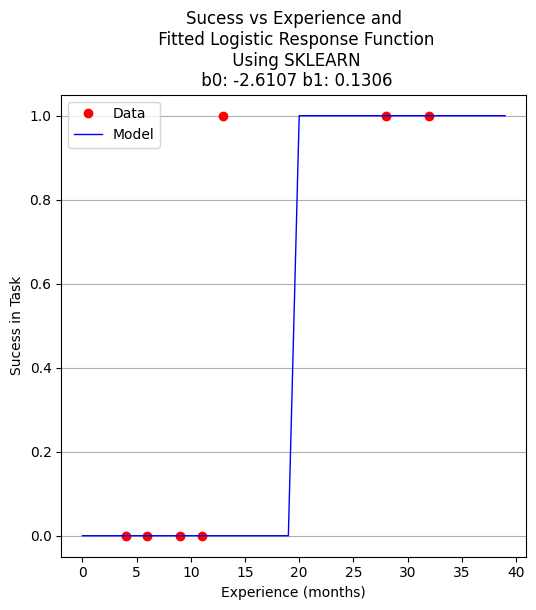

In [20]:
plottitle = 'Sucess vs Experience and\n Fitted Logistic Response Function\n Using SKLEARN\n '+'b0: '+ str(round(b0,4)) + ' b1: ' + str(round(b1,4))
make2plot(X_test,y_test,xaxis,fitted,'Experience (months)','Sucess in Task',plottitle)

In [21]:
# import the metrics class
from sklearn import metrics
cnf_matrix = metrics.confusion_matrix(y_pred, y_test)
cnf_matrix

array([[4, 1],
       [0, 2]])

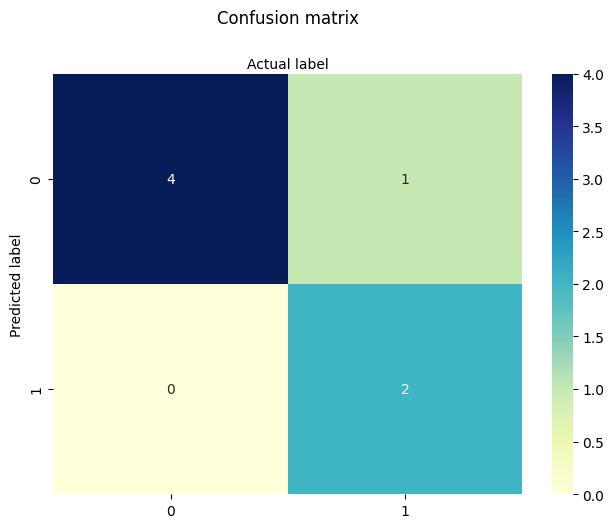

In [22]:
import seaborn as sns
import pandas as pd
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Predicted label')
plt.xlabel('Actual label');

In [23]:
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))
print("Precision:",metrics.precision_score(y_test, y_pred))
print("Recall:",metrics.recall_score(y_test, y_pred))
print("F1-score:",metrics.f1_score(y_test, y_pred))

Accuracy: 0.8571428571428571
Precision: 1.0
Recall: 0.6666666666666666
F1-score: 0.8


In [24]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      1.00      0.89         4
           1       1.00      0.67      0.80         3

    accuracy                           0.86         7
   macro avg       0.90      0.83      0.84         7
weighted avg       0.89      0.86      0.85         7



In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report


In [26]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def make1plot(x, y, xlabel, ylabel, title):
    plt.figure(figsize=(6, 6))
    plt.plot(x, y, 'o')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.show()


In [27]:
# Simulate experience (months) and probability of success
np.random.seed(42)
experience = np.linspace(0, 12, 50).reshape(-1, 1)
true_params = [0.8, -4.5]
logit_score = true_params[0] * experience + true_params[1]
prob_success = sigmoid(logit_score)
result = np.random.binomial(1, prob_success.ravel())  # Binary outcome


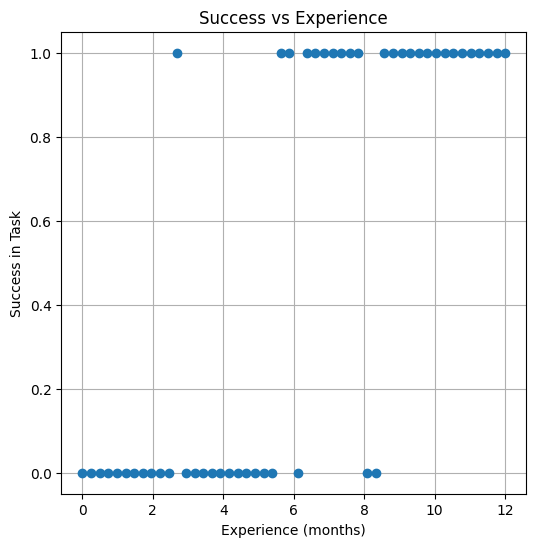

In [28]:
make1plot(experience, result, "Experience (months)", "Success in Task", "Success vs Experience")


In [29]:
model = LogisticRegression()
model.fit(experience, result)

# Predict probability over a finer grid
x_pred = np.linspace(0, 12, 200).reshape(-1, 1)
y_pred = model.predict_proba(x_pred)[:, 1]


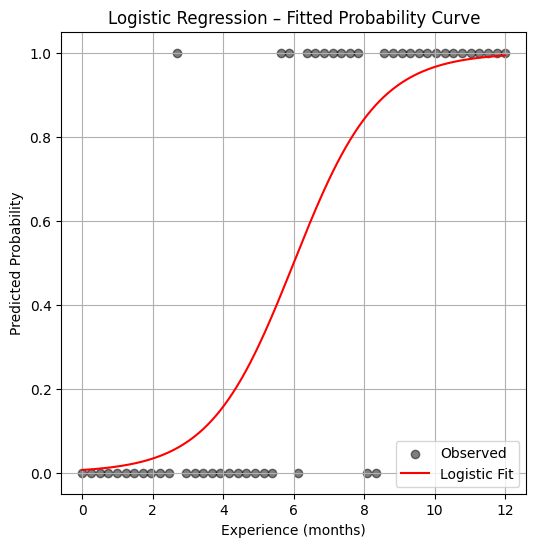

In [30]:
plt.figure(figsize=(6, 6))
plt.scatter(experience, result, label="Observed", color="black", alpha=0.5)
plt.plot(x_pred, y_pred, color="red", label="Logistic Fit")
plt.xlabel("Experience (months)")
plt.ylabel("Predicted Probability")
plt.title("Logistic Regression – Fitted Probability Curve")
plt.legend()
plt.grid(True)
plt.show()


In [31]:
y_pred_binary = model.predict(experience)
print(confusion_matrix(result, y_pred_binary))
print(classification_report(result, y_pred_binary))


[[22  3]
 [ 3 22]]
              precision    recall  f1-score   support

           0       0.88      0.88      0.88        25
           1       0.88      0.88      0.88        25

    accuracy                           0.88        50
   macro avg       0.88      0.88      0.88        50
weighted avg       0.88      0.88      0.88        50



In [32]:
%reset -f
# Load The Data
level = [1,2,3,4,5]
reduction = [5,10,15,20,30]
participants = [200,200,200,200,200]
redeemed = [30,55,70,100,137]
proportion = [0 for i in range(len(level))]
for i in range(len(proportion)):
    proportion[i]=redeemed[i]/participants[i]

In [33]:
import matplotlib.pyplot as plt
def make1plot(listx1,listy1,strlablx,strlably,strtitle):
    mydata = plt.figure(figsize = (6,6)) # build a square drawing canvass from figure class
    plt.plot(listx1,listy1, c='red', marker='o',linewidth=0) # basic data plot
    plt.xlabel(strlablx)
    plt.ylabel(strlably)
    plt.legend(['Data','Model'])# modify for argument insertion
    plt.title(strtitle)
    plt.grid(axis='y')
    plt.show()

def make2plot(listx1,listy1,listx2,listy2,strlablx,strlably,strtitle):
    mydata = plt.figure(figsize = (6,6)) # build a square drawing canvass from figure class
    plt.plot(listx1,listy1, c='red', marker='v',linewidth=0) # basic data plot
    plt.plot(listx2,listy2, c='blue',linewidth=1) # basic model plot
    plt.grid(which='both',axis='both')
    plt.xlabel(strlablx)
    plt.ylabel(strlably)
    plt.legend(['Data','Model'])# modify for argument insertion
    plt.title(strtitle)
    plt.grid(axis='y')
    plt.show()

%matplotlib inline

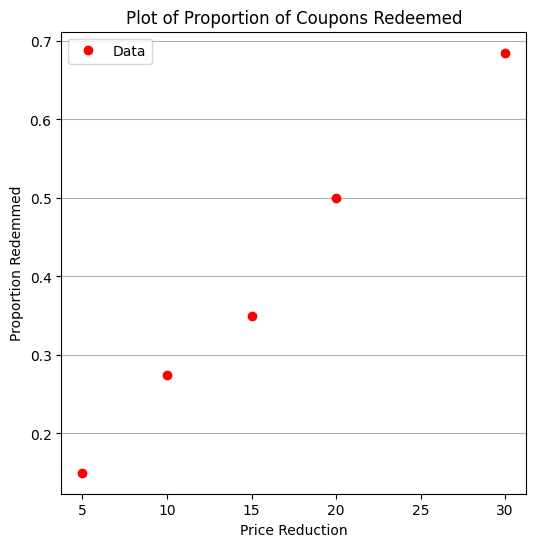

In [34]:
make1plot(reduction,proportion,'Price Reduction','Proportion Redemmed','Plot of Proportion of Coupons Redeemed')

In [35]:
def pii(b0,b1,x): #sigmoidal function
    import math
    pii = math.exp(b0+b1*x)/(1+ math.exp(b0+b1*x))
    return(pii)

def sse(mod,obs): #compute sse from observations and model values
    howmany = len(mod)
    sse=0.0
    for i in range(howmany):
        sse=sse+(mod[i]-obs[i])**2
    return(sse)

def merit(beta): # merit function to minimize
    global proportion,reduction #access lists already defined external to function
    mod=[0 for i in range(len(proportion))]
    for i in range(len(level)):
        mod[i]=pii(beta[0],beta[1],reduction[i])
    merit = sse(mod,proportion)
    return(merit)


In [36]:
beta = [0,0] # initial guess
merit(beta) # test for exceptions

0.22985

Optimization terminated successfully.
         Current function value: 0.002032
         Iterations: 3
         Function evaluations: 81
 b0 =  -2.0165402749739756
 b1 =  0.09580373659184761


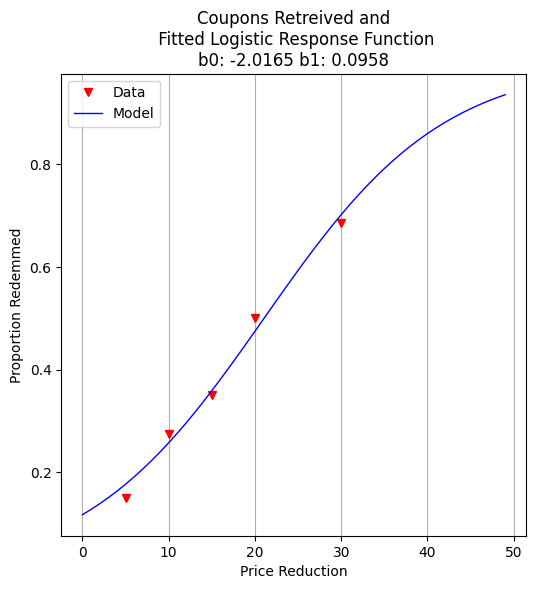

In [37]:
import numpy as np
from scipy.optimize import minimize

x0 = np.array([-2,0.09])
res = minimize(merit, x0, method='powell',options={'disp': True})
# 
fitted=[0 for i in range(50)]
xaxis =[0 for i in range(50)]
for i in range(50):
    xaxis[i]=float(i)
    fitted[i]=pii(res.x[0],res.x[1],float(i))
    
print(" b0 = ",res.x[0])
print(" b1 = ",res.x[1])

plottitle = 'Coupons Retreived and\n Fitted Logistic Response Function\n'+'b0: '+ str(round(res.x[0],4))+ ' b1: ' +str(round(res.x[1],4))
make2plot(reduction,proportion,xaxis,fitted,'Price Reduction','Proportion Redemmed',plottitle)

In [38]:
guess = 21.05
fraction = pii(res.x[0],res.x[1],guess)
print("For Reduction of ",guess," projected redemption rate is ",round(fraction,3))

For Reduction of  21.05  projected redemption rate is  0.5


In [39]:
guess = 61.90
fraction = pii(res.x[0],res.x[1],guess)
print("For Reduction of ",guess," projected redemption rate is ",round(fraction,3))

For Reduction of  61.9  projected redemption rate is  0.98


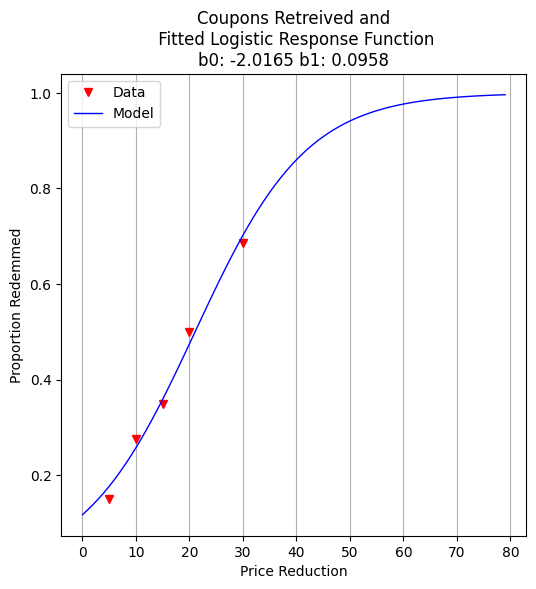

In [40]:
fitted=[0 for i in range(80)]
xaxis =[0 for i in range(80)]
for i in range(80):
    xaxis[i]=float(i)
    fitted[i]=pii(res.x[0],res.x[1],float(i))

plottitle = 'Coupons Retreived and\n Fitted Logistic Response Function\n'+'b0: '+ str(round(res.x[0],4))+ ' b1: ' +str(round(res.x[1],4))
make2plot(reduction,proportion,xaxis,fitted,'Price Reduction','Proportion Redemmed',plottitle)

   Rebate  Participants  Redeemed  Proportion
0       5           201        37    0.184080
1      10           242        81    0.334711
2      15           164        71    0.432927
3      20           221       145    0.656109
4      30           210       175    0.833333


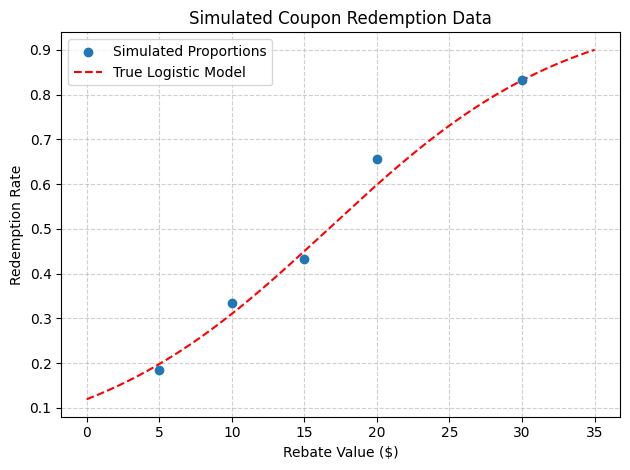

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set seed for repeatability
np.random.seed(42)

# Define rebate levels (predictor values)
rebate_levels = np.array([5, 10, 15, 20, 30])

# Randomize number of participants per level (e.g., between 150 and 250)
participants_per_level = np.random.randint(150, 250, size=len(rebate_levels))

# Define true logistic model parameters for simulation
true_intercept = -2.0
true_slope = 0.12

# Compute true probability of redemption at each level
def logistic(x, b0=true_intercept, b1=true_slope):
    return 1 / (1 + np.exp(-(b0 + b1 * x)))

true_probs = logistic(rebate_levels)

# Simulate number of redemptions as binomial draws
redemptions = np.random.binomial(participants_per_level, true_probs)

# Assemble the simulated dataset
simulated_data = pd.DataFrame({
    'Rebate': rebate_levels,
    'Participants': participants_per_level,
    'Redeemed': redemptions,
    'Proportion': redemptions / participants_per_level
})

# Show the dataset
print(simulated_data)

# Optional: plot the simulated proportions and true logistic curve
x_plot = np.linspace(0, 35, 200)
plt.scatter(rebate_levels, simulated_data['Proportion'], label='Simulated Proportions', zorder=3)
plt.plot(x_plot, logistic(x_plot), 'r--', label='True Logistic Model')
plt.xlabel('Rebate Value ($)')
plt.ylabel('Redemption Rate')
plt.title('Simulated Coupon Redemption Data')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


   Rebate  Intercept  Participants  Redeemed  Proportion
0       5     -1.544           216        58    0.268519
1      10     -2.014           242        84    0.347107
2      15     -1.521           248       140    0.564516
3      20     -2.535           167        80    0.479042
4      30     -2.086           233       185    0.793991


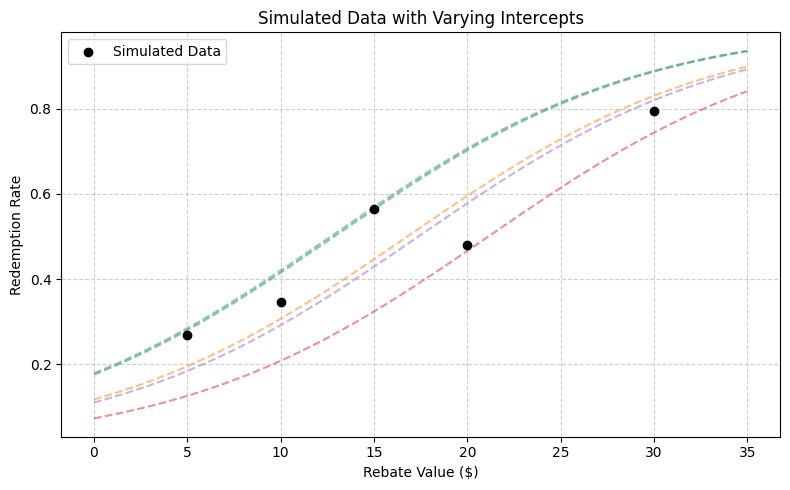

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set seed for reproducibility
np.random.seed(123)

# Define rebate levels (predictor values)
rebate_levels = np.array([5, 10, 15, 20, 30])

# Randomize number of participants per level
participants_per_level = np.random.randint(150, 251, size=len(rebate_levels))

# Base logistic model slope (kept fixed)
true_slope = 0.12

# Define intercepts that vary by rebate level
# (e.g., due to regional or marketing channel effects)
base_intercept = -2.0
intercept_variation = np.random.normal(loc=0, scale=0.3, size=len(rebate_levels))
varying_intercepts = base_intercept + intercept_variation

# Define logistic function with per-level intercepts
def logistic(x, b0, b1=true_slope):
    return 1 / (1 + np.exp(-(b0 + b1 * x)))

# Compute probabilities and simulate redemptions
true_probs = [logistic(x, b0) for x, b0 in zip(rebate_levels, varying_intercepts)]
redemptions = np.random.binomial(participants_per_level, true_probs)

# Assemble dataset
simulated_data = pd.DataFrame({
    'Rebate': rebate_levels,
    'Intercept': np.round(varying_intercepts, 3),
    'Participants': participants_per_level,
    'Redeemed': redemptions,
    'Proportion': redemptions / participants_per_level
})

# Display the simulated data
print(simulated_data)

# Plot: Simulated data points and multiple logistic curves
x_plot = np.linspace(0, 35, 300)
plt.figure(figsize=(8, 5))

# Plot each individual curve
for i, (b0, label) in enumerate(zip(varying_intercepts, rebate_levels)):
    plt.plot(x_plot, logistic(x_plot, b0), linestyle='--', alpha=0.5)

# Overlay simulated points
plt.scatter(rebate_levels, simulated_data['Proportion'], color='black', label='Simulated Data', zorder=5)
plt.xlabel('Rebate Value ($)')
plt.ylabel('Redemption Rate')
plt.title('Simulated Data with Varying Intercepts')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


In [43]:
%reset -f
# get data
import pandas as pd
df = pd.read_csv("APC3.DAT",
                header=0,index_col=["CASE"],
                usecols=["CASE","AGE","INCOME","SECTOR","SICK"])
df.head()

,AGE,INCOME,SECTOR,SICK
CASE,,,,
1,33,1,1,0
2,35,1,1,0
3,6,1,1,0
4,60,1,1,0
5,18,3,1,1


In [44]:
df.describe()

,AGE,INCOME,SECTOR,SICK
count,196.000000,196.000000,196.000000,196.000000
mean,25.178571,1.964286,1.403061,0.290816
std,18.904721,0.867505,0.491769,0.455302
min,1.000000,1.000000,1.000000,0.000000
25%,10.750000,1.000000,1.000000,0.000000
50%,21.000000,2.000000,1.000000,0.000000
75%,35.000000,3.000000,2.000000,1.000000
max,85.000000,3.000000,2.000000,1.000000


In [45]:
df["X2"]=0
df["X3"]=0
df.head()

,AGE,INCOME,SECTOR,SICK,X2,X3
CASE,,,,,,
1,33,1,1,0,0,0
2,35,1,1,0,0,0
3,6,1,1,0,0,0
4,60,1,1,0,0,0
5,18,3,1,1,0,0


In [46]:
def isone(a):
    if a == 1:
        isone = 1
    else:
        isone = 0
    return(isone)

def istwo(a):
    if a == 2:
        isone = 1
    else:
        isone = 0
    return(isone)

def isthree(a):
    if a == 3:
        isone = 1
    else:
        isone = 0
    return(isone)

In [47]:
df["X2"]=df["INCOME"].apply(istwo)
df["X3"]=df["INCOME"].apply(isone)

In [48]:
df.head()

,AGE,INCOME,SECTOR,SICK,X2,X3
CASE,,,,,,
1,33,1,1,0,0,1
2,35,1,1,0,0,1
3,6,1,1,0,0,1
4,60,1,1,0,0,1
5,18,3,1,1,0,0


In [49]:
def pii(b0,b1,b2,b3,b4,x1,x2,x3,x4): #sigmoidal function
    import math
    pii = math.exp(b0+b1*x1+b2*x2+b3*x3+b4*x4)/(1+ math.exp(b0+b1*x1+b2*x2+b3*x3+b4*x4))
    return(pii)

In [50]:
def sse(mod,obs): #compute sse from observations and model values
    howmany = len(mod)
    sse=0.0
    for i in range(howmany):
        sse=sse+(mod[i]-obs[i])**2
    return(sse)

In [51]:
feature_cols = ['AGE', 'X2','X3', 'SECTOR']
Xmat = df[feature_cols].values # Features as an array (not a dataframe)
Yvec = df["SICK"].values # Target as a vector (not a dataframe)

In [52]:
def merit(beta): # merit function to minimize
    global Yvec,Xmat #access lists already defined external to function
    mod=[0 for i in range(len(Yvec))]
    for i in range(len(Yvec)):
        mod[i]=pii(beta[0],beta[1],beta[2],beta[3],beta[4],Xmat[i][0],Xmat[i][1],Xmat[i][2],Xmat[i][3])
    merit = sse(mod,Yvec)
    return(merit)

In [53]:
beta=[0,0,0,0,0]
irow = 1
print("The pi function ",pii(beta[0],beta[1],beta[2],beta[3],beta[4],Xmat[irow][0],Xmat[irow][1],Xmat[irow][2],Xmat[irow][3]))
print("The merit function ",merit(beta))

The pi function  0.5
The merit function  49.0


In [54]:
import numpy as np
from scipy.optimize import minimize

x0 = np.array(beta)
res = minimize(merit, x0, method='powell',options={'disp': True})
# 
fitted=[0 for i in range(90)]
xaxis_age =[0 for i in range(90)]
#xaxis_sector =[0 for i in range(90)]
#xaxis_x2 =[0 for i in range(90)]
#xaxis_x3 =[0 for i in range(90)]

sector_tmp = 1 # some sector
x2_tmp = 0 #  not poor
x3_tmp = 0 # not middle

for i in range(90):
    xaxis_age[i]=float(i)
    fitted[i]=pii(res.x[0],res.x[1],res.x[2],res.x[3],res.x[4],xaxis_age[i],x2_tmp,x3_tmp,sector_tmp)
    
print(" b0 = ",res.x[0])
print(" b1 = ",res.x[1])
print(" b2 = ",res.x[2])
print(" b3 = ",res.x[3])
print(" b4 = ",res.x[4])

Optimization terminated successfully.
         Current function value: 35.382536
         Iterations: 8
         Function evaluations: 460
 b0 =  -3.219051882695808
 b1 =  0.024207668771930674
 b2 =  -0.13015812819127218
 b3 =  -0.25363504886581595
 b4 =  1.2449844422211769


In [55]:
# Load a Plotting Tool
import matplotlib.pyplot as plt
def make1plot(listx1,listy1,strlablx,strlably,strtitle):
    mydata = plt.figure(figsize = (6,6)) # build a square drawing canvass from figure class
    plt.plot(listx1,listy1, c='red', marker='o',linewidth=0) # basic data plot
    plt.xlabel(strlablx)
    plt.ylabel(strlably)
    plt.legend(['Data','Model'])# modify for argument insertion
    plt.title(strtitle)
    plt.grid(axis='y')
    plt.show()
def make2plot(listx1,listy1,listx2,listy2,strlablx,strlably,strtitle):
    mydata = plt.figure(figsize = (6,6)) # build a square drawing canvass from figure class
    plt.plot(listx1,listy1, c='red', marker='o',linewidth=0) # basic data plot
    plt.plot(listx2,listy2, c='blue',linewidth=1) # basic model plot
    plt.xlabel(strlablx)
    plt.ylabel(strlably)
    plt.legend(['Data','Model'])# modify for argument insertion
    plt.title(strtitle)
    plt.grid(axis='y')
    plt.show()
 
xobs = [0 for i in range(len(Xmat))]
for i in range(len(Xmat)):    
    xobs[i] = Xmat[i][0]


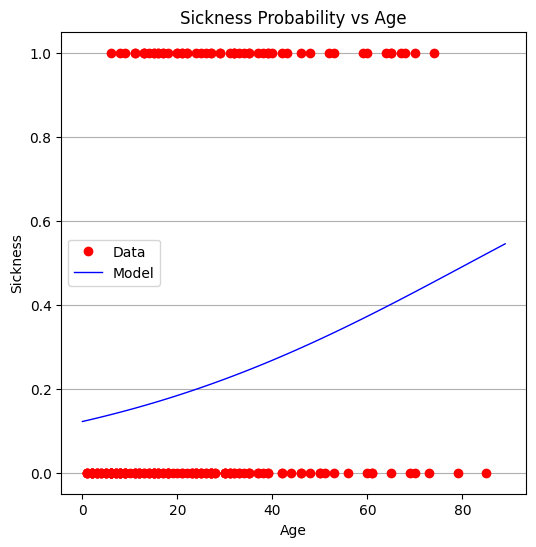

In [56]:
plottitle = 'Sickness Probability vs Age'
make2plot(xobs,Yvec,xaxis_age,fitted,'Age','Sickness',plottitle)

In [57]:
#split dataset in features and target variable
#feature_cols = ['AGE']
#feature_cols = ['AGE', 'SECTOR']
feature_cols = ['AGE', 'X2','X3', 'SECTOR']
X = df[feature_cols] # Features
y = df["SICK"] # Target variable

In [58]:
# split X and y into training and testing sets
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=0)

In [59]:
# import the class
from sklearn.linear_model import LogisticRegression

# instantiate the model (using the default parameters)
#logreg = LogisticRegression()
logreg = LogisticRegression()
# fit the model with data
logreg.fit(X_train,y_train)

#
y_pred=logreg.predict(X_test)

In [60]:
print(logreg.intercept_[0])
print(logreg.coef_)
#y.head()

-3.8678278714188528
[[ 0.02518861  0.18701833 -0.22604932  1.51451584]]


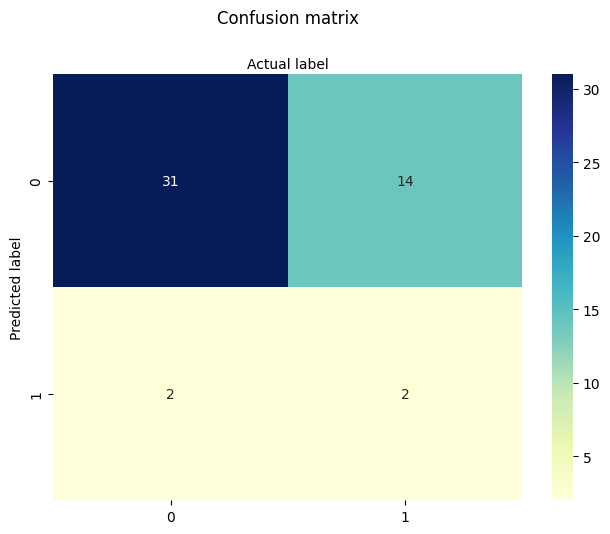

In [61]:
# import the metrics class
from sklearn import metrics
cnf_matrix = metrics.confusion_matrix(y_pred, y_test)
cnf_matrix
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Predicted label')
plt.xlabel('Actual label');

-1.7238065116617818
[[0.02719036]]


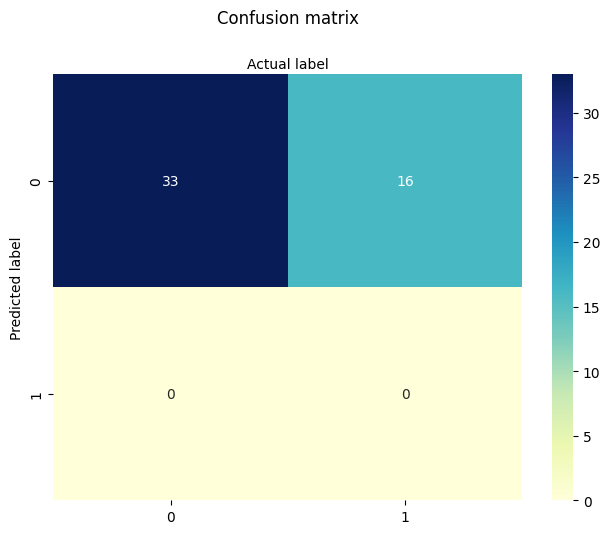

In [62]:
#split dataset in features and target variable
feature_cols = ['AGE']
#feature_cols = ['AGE', 'SECTOR']
#feature_cols = ['AGE', 'X2','X3', 'SECTOR']
X = df[feature_cols] # Features
y = df["SICK"] # Target variable
# split X and y into training and testing sets
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=0)
# import the class
from sklearn.linear_model import LogisticRegression

# instantiate the model (using the default parameters)
#logreg = LogisticRegression()
logreg = LogisticRegression()
# fit the model with data
logreg.fit(X_train,y_train)

#
y_pred=logreg.predict(X_test)
print(logreg.intercept_[0])
print(logreg.coef_)
# import the metrics class
from sklearn import metrics
cnf_matrix = metrics.confusion_matrix(y_pred, y_test)
cnf_matrix
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Predicted label')
plt.xlabel('Actual label');

-1.1389014522629408
[[0.3963004  0.21673499]]


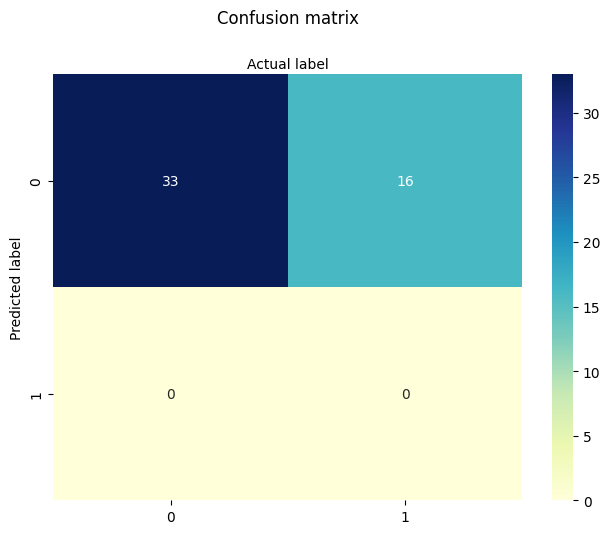

In [63]:
#split dataset in features and target variable
#feature_cols = ['AGE']
#feature_cols = ['SECTOR']
feature_cols = ['X2','X3']
#feature_cols = ['AGE', 'X2','X3', 'SECTOR']
X = df[feature_cols] # Features
y = df["SICK"] # Target variable
# split X and y into training and testing sets
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=0)
# import the class
from sklearn.linear_model import LogisticRegression

# instantiate the model (using the default parameters)
#logreg = LogisticRegression()
logreg = LogisticRegression()
# fit the model with data
logreg.fit(X_train,y_train)
y_pred=logreg.predict(X_test)
print(logreg.intercept_[0])
print(logreg.coef_)
# import the metrics class
from sklearn import metrics
cnf_matrix = metrics.confusion_matrix(y_pred, y_test)
cnf_matrix
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Predicted label')
plt.xlabel('Actual label');

-3.265050761147032
[[1.56248233]]


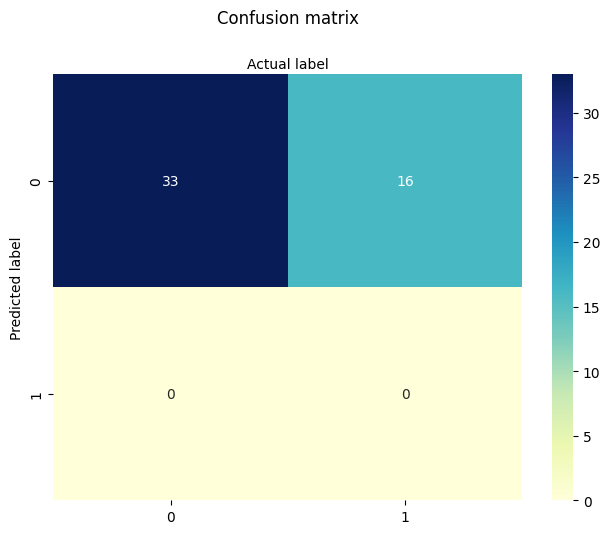

In [64]:
#split dataset in features and target variable
#feature_cols = ['AGE']
feature_cols = ['SECTOR']
#feature_cols = ['X2','X3']
#feature_cols = ['AGE', 'X2','X3', 'SECTOR']
X = df[feature_cols] # Features
y = df["SICK"] # Target variable
# split X and y into training and testing sets
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=0)
# import the class
from sklearn.linear_model import LogisticRegression

# instantiate the model (using the default parameters)
#logreg = LogisticRegression()
logreg = LogisticRegression()
# fit the model with data
logreg.fit(X_train,y_train)
y_pred=logreg.predict(X_test)
print(logreg.intercept_[0])
print(logreg.coef_)
# import the metrics class
from sklearn import metrics
cnf_matrix = metrics.confusion_matrix(y_pred, y_test)
cnf_matrix
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Predicted label')
plt.xlabel('Actual label');

-3.8498269191334367
[[0.02426237 1.49033741]]


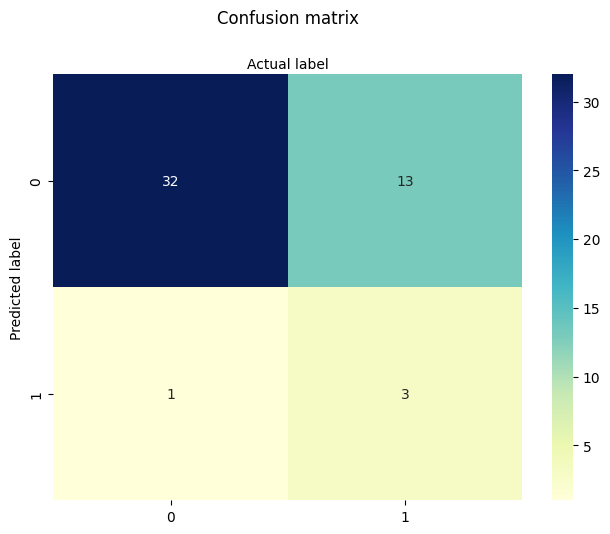

In [65]:
#split dataset in features and target variable
#feature_cols = ['AGE']
#feature_cols = ['SECTOR']
feature_cols = ['AGE','SECTOR']
#feature_cols = ['AGE', 'X2','X3', 'SECTOR']
X = df[feature_cols] # Features
y = df["SICK"] # Target variable
# split X and y into training and testing sets
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=0)
# import the class
from sklearn.linear_model import LogisticRegression

# instantiate the model (using the default parameters)
#logreg = LogisticRegression()
logreg = LogisticRegression()
# fit the model with data
logreg.fit(X_train,y_train)
y_pred=logreg.predict(X_test)
print(logreg.intercept_[0])
print(logreg.coef_)
# import the metrics class
from sklearn import metrics
cnf_matrix = metrics.confusion_matrix(y_pred, y_test)
cnf_matrix
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Predicted label')
plt.xlabel('Actual label');

In [66]:
%reset -f
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import requests
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Try to download the dataset from GitHub (fallback to local if needed)
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
filename = "titanic.csv"

if not os.path.exists(filename):
    try:
        response = requests.get(url)
        with open(filename, 'wb') as f:
            f.write(response.content)
        print(f"Dataset downloaded and saved as '{filename}'")
    except Exception as e:
        print(f"Could not download file. Please ensure '{filename}' is available locally.\n", e)

# Load dataset
df = pd.read_csv(filename)

# Display sample
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [67]:
# Drop columns that are not immediately useful or too messy (Name, Ticket, Cabin)
df = df.drop(columns=['Name', 'Ticket', 'Cabin'])

# Handle missing values
df = df.dropna(subset=['Embarked'])              # drop rows with missing Embarked
df['Age'] = df['Age'].fillna(df['Age'].median()) # fill missing Age with median
df['Fare'] = df['Fare'].fillna(df['Fare'].median()) # fill Fare if needed

# Display sample
print(df.head())

   PassengerId  Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0            1         0       3    male  22.0      1      0   7.2500        S
1            2         1       1  female  38.0      1      0  71.2833        C
2            3         1       3  female  26.0      0      0   7.9250        S
3            4         1       1  female  35.0      1      0  53.1000        S
4            5         0       3    male  35.0      0      0   8.0500        S


In [68]:
# Encode categorical variables
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

# Features and target
X = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']]
y = df['Survived']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1912)

# Fit logistic regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Coefficient interpretation
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0],
    'Odds Ratio': np.exp(model.coef_[0])
}).sort_values('Odds Ratio', ascending=False)

print("\nModel Coefficients and Odds Ratios:")
print(coef_df)


Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.86      0.83       111
           1       0.73      0.66      0.69        67

    accuracy                           0.78       178
   macro avg       0.77      0.76      0.76       178
weighted avg       0.78      0.78      0.78       178

Confusion Matrix:
 [[95 16]
 [23 44]]

Model Coefficients and Odds Ratios:
      Feature  Coefficient  Odds Ratio
1         Sex     2.706257   14.973123
5        Fare     0.001798    1.001799
2         Age    -0.037653    0.963047
6  Embarked_Q    -0.066455    0.935705
4       Parch    -0.098388    0.906297
3       SibSp    -0.332609    0.717051
7  Embarked_S    -0.444609    0.641075
0      Pclass    -1.128217    0.323610


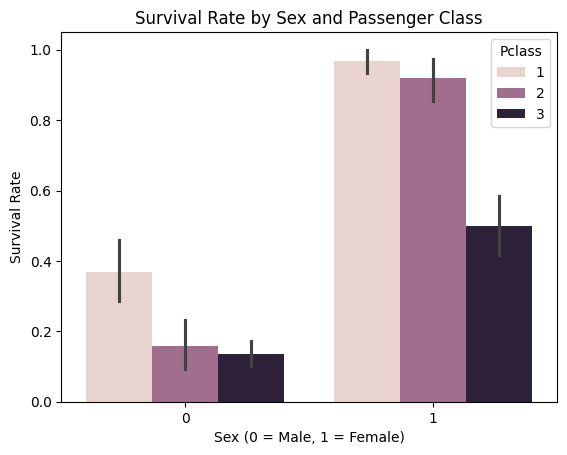

In [69]:
# Plot: Survival rate by Sex and Pclass
sns.barplot(data=df, x='Sex', y='Survived', hue='Pclass')
plt.title("Survival Rate by Sex and Passenger Class")
plt.xlabel("Sex (0 = Male, 1 = Female)")
plt.ylabel("Survival Rate")
plt.show()


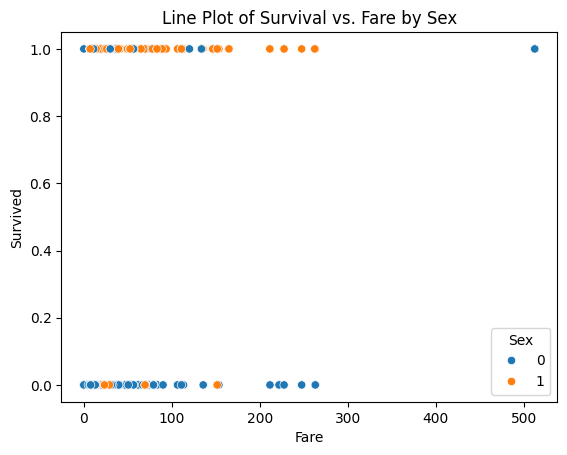

In [70]:

# Plot: Survival rate by Sex and Pclass
sns.scatterplot(x="Fare", y="Survived", hue="Sex", data=df)
plt.title("Line Plot of Survival vs. Fare by Sex")
plt.show()


In [71]:
filtered_male_df = df.loc[df['Sex'] == 0]
# Features and target
X = filtered_male_df[['Fare']]
y = filtered_male_df['Survived']
#print(len(X))

In [72]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1912)

In [73]:
# Fit logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train);

In [74]:
# Evaluate
y_pred = model.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.98      0.91        99
           1       0.00      0.00      0.00        17

    accuracy                           0.84       116
   macro avg       0.43      0.49      0.46       116
weighted avg       0.73      0.84      0.78       116

Confusion Matrix:
 [[97  2]
 [17  0]]


In [75]:
X_train.describe()

,Fare
count,461.000000
mean,25.326824
std,44.374488
min,0.000000
25%,7.854200
50%,11.500000
75%,26.550000
max,512.329200


In [76]:
import warnings
warnings.filterwarnings('ignore')
# Predict probability over grid
x_pred = np.linspace(0, 500, 200).reshape(-1, 1)
y_pred = model.predict_proba(x_pred)[:, 1]

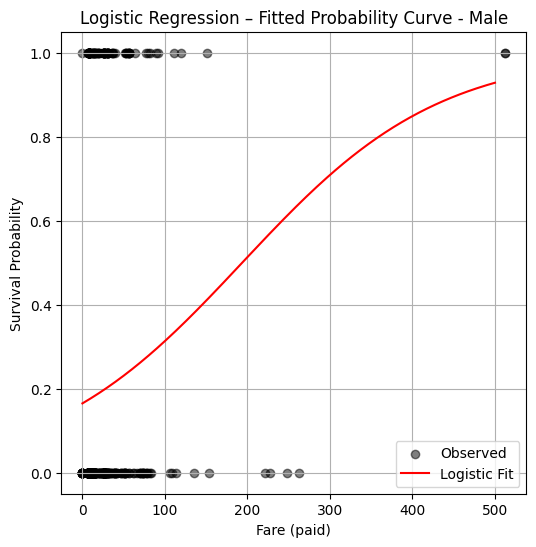

In [77]:
plt.figure(figsize=(6, 6))
plt.scatter(X_train, y_train, label="Observed", color="black", alpha=0.5)
plt.plot(x_pred, y_pred, color="red", label="Logistic Fit")
plt.xlabel("Fare (paid)")
plt.ylabel("Survival Probability")
plt.title("Logistic Regression – Fitted Probability Curve - Male")
plt.legend()
plt.grid(True)
plt.show()

In [78]:
import warnings
warnings.filterwarnings('ignore')
filtered_female_df = df.loc[df['Sex'] == 1]
# Features and target
X = filtered_female_df[['Fare']]
y = filtered_female_df['Survived']
print(len(X))
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1912)
# Fit logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
# Predict probability over grid
x_pred = np.linspace(0, 500, 200).reshape(-1, 1)
y_pred = model.predict_proba(x_pred)[:, 1]

312


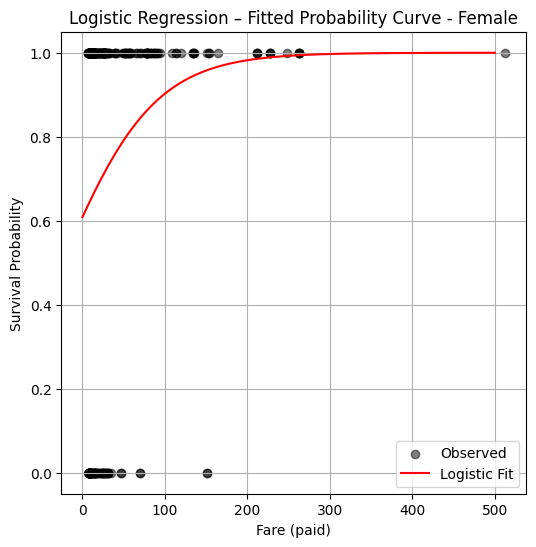

In [79]:
plt.figure(figsize=(6, 6))
plt.scatter(X_train, y_train, label="Observed", color="black", alpha=0.5)
plt.plot(x_pred, y_pred, color="red", label="Logistic Fit")
plt.xlabel("Fare (paid)")
plt.ylabel("Survival Probability")
plt.title("Logistic Regression – Fitted Probability Curve - Female")
plt.legend()
plt.grid(True)
plt.show()

In [80]:
import sys # Module to process commands to/from the OS using a shell-type syntax
import requests
remote_url="http://54.243.252.9/ce-5319-webroot/ce5319jb/lessons/logisticregression/agaricus-lepiota.data"  # set the url
rget = requests.get(remote_url, allow_redirects=True)  # get the remote resource, follow imbedded links
localfile = open('poisonmushroom.csv','wb') # open connection to a local file same name as remote
localfile.write(rget.content) # extract from the remote the contents,insert into the local file same name
localfile.close() # close connection to the local file
# delete file if it exists

In [81]:
import pandas as pd
mymushroom = pd.read_csv('poisonmushroom.csv',header=None)

attributes=['poison-class','cap-shape','cap-surface','cap-color','bruises','odor','gill-attachment','gill-spacing','gill-size','gill-color','stalk-shape','stalk-root','stalk-surface-above-ring','stalk-surface-below-ring','stalk-color-above-ring','stalk-color-below-ring','veil-type','veil-color','ring-number','ring-type','spore-print-color','population','habitat']
len(attributes)

req_col_names = attributes
curr_col_names = list(mymushroom.columns)

mapper = {}
for i, name in enumerate(curr_col_names):
    mapper[name] = req_col_names[i]

mymushroom = mymushroom.rename(columns=mapper)
interim = pd.DataFrame(mymushroom)
mymushroom.head(20)

,poison-class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
5,e,x,y,y,t,a,f,c,b,n,...,s,w,w,p,w,o,p,k,n,g
6,e,b,s,w,t,a,f,c,b,g,...,s,w,w,p,w,o,p,k,n,m
7,e,b,y,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,s,m
8,p,x,y,w,t,p,f,c,n,p,...,s,w,w,p,w,o,p,k,v,g
9,e,b,s,y,t,a,f,c,b,g,...,s,w,w,p,w,o,p,k,s,m


In [82]:
def p0(stringvalue):
    if stringvalue == 'e':
        p0 = 0
    elif stringvalue == 'p':
        p0 = 1
    else: 
        raise Exception("Encoding failed in p0 missing data maybe?")
    return(p0)
######################################################################
# Feature Encoding Functions using a Simple Substitution Cipher     ##
######################################################################
def c1(stringvalue):
#cap-shape:  bell=b,conical=c,convex=x,flat=f,knobbed=k,sunken=s
    ncode=True # set exception flag
    alphabet=['b','c','x','f','k','s']
    for i in range(len(alphabet)):
        if stringvalue == alphabet[i]:
            c1=i+1
            ncode=False #  if encoding swithc flag value
    if ncode:
        raise Exception("Encoding failed in c1 missing data maybe?")
    return(c1)
######################################################################
def c2(stringvalue):
#cap-surface: fibrous=f,grooves=g,scaly=y,smooth=s
    ncode=True
    alphabet=['f','g','y','s']
    for i in range(len(alphabet)):
        if stringvalue == alphabet[i]:
            c2=i+1
            ncode=False
    if ncode:
        raise Exception("Encoding failed in c2 missing data maybe?")
    return(c2)
######################################################################
def c3(stringvalue):
#cap-color: brown=n,buff=b,cinnamon=c,gray=g,green=r,pink=p,purple=u,red=e,white=w,yellow=y
    ncode=True
    alphabet=['n','b','c','g','r','p','u','e','w','y']
    for i in range(len(alphabet)):
        if stringvalue == alphabet[i]:
            c3=i+1
            ncode=False
    if ncode:
        raise Exception("Encoding failed in c3 missing data maybe?")
    return(c3)
######################################################################
def c4(stringvalue): #this is a simple binary encoding column
#bruises?:bruises=t,no=f
    ncode=True
    alphabet=['f','t']
    for i in range(len(alphabet)):
        if stringvalue == alphabet[i]:
            c4=i+1
            ncode=False
    if ncode:
        raise Exception("Encoding failed in c4 missing data maybe?")
    return(c4)
######################################################################
def c5(stringvalue):
#odor:  almond=a,anise=l,creosote=c,fishy=y,foul=f,musty=m,none=n,pungent=p,spicy=s
    ncode=True
    alphabet=['a','l','c','y','f','m','n','p','s']
    for i in range(len(alphabet)):
        if stringvalue == alphabet[i]:
            c5=i+1
            ncode=False
    if ncode:
        raise Exception("Encoding failed in c5 missing data maybe?")
    return(c5)
######################################################################
def c6(stringvalue):
#gill-attachment: attached=a,descending=d,free=f,notched=n
    ncode=True
    alphabet=['a','d','f','n']
    for i in range(len(alphabet)):
        if stringvalue == alphabet[i]:
            c6=i+1
            ncode=False
    if ncode:
        raise Exception("Encoding failed in c6 missing data maybe?")
    return(c6)
######################################################################
def c7(stringvalue):
#gill-spacing: close=c,crowded=w,distant=d
    ncode=True
    alphabet=['c','w','d']
    for i in range(len(alphabet)):
        if stringvalue == alphabet[i]:
            c7=i+1
            ncode=False
    if ncode:
        raise Exception("Encoding failed in c7 missing data maybe?")
    return(c7)
######################################################################
def c8(stringvalue):
#gill-size:  broad=b,narrow=n
    ncode=True
    alphabet=['b','n']
    for i in range(len(alphabet)):
        if stringvalue == alphabet[i]:
            c8=i+1
            ncode=False
    if ncode:
        raise Exception("Encoding failed in c8 missing data maybe?")
    return(c8)
######################################################################
def c9(stringvalue):
#gill-color: black=k,brown=n,buff=b,chocolate=h,gray=g,green=r,orange=o,pink=p,purple=u,red=e,white=w,yellow=y
    ncode=True
    alphabet=['k','n','b','h','g','r','o','p','u','e','w','y']
    for i in range(len(alphabet)):
        if stringvalue == alphabet[i]:
            c9=i+1
            ncode=False
    if ncode:
        raise Exception("Encoding failed in c9 missing data maybe?")
    return(c9)
######################################################################
def c10(stringvalue):
#stalk-shape:enlarging=e,tapering=t
    ncode=True
    alphabet=['e','t']
    for i in range(len(alphabet)):
        if stringvalue == alphabet[i]:
            c10=i+1
            ncode=False
    if ncode:
        raise Exception("Encoding failed in c10 missing data maybe?")
    return(c10)
######################################################################
def c11(stringvalue):
#stalk-root: bulbous=b,club=c,cup=u,equal=e,rhizomorphs=z,rooted=r,missing=?
    ncode=True
    alphabet=['b','c','u','e','z','r','?'] # set missing to zero position
    for i in range(len(alphabet)):
        if stringvalue == alphabet[i]:
            c11=i+1
            ncode=False
    if ncode:
        raise Exception("Encoding failed in c11 missing data maybe?")
    return(c11)
######################################################################
def c12(stringvalue):
#stalk-surface-above-ring: fibrous=f,scaly=y,silky=k,smooth=s
    ncode=True
    alphabet=['f','y','k','s','?'] # set missing to zero position
    for i in range(len(alphabet)):
        if stringvalue == alphabet[i]:
            c12=i+1
            ncode=False
    if ncode:
        raise Exception("Encoding failed in c12 missing data maybe?")
    return(c12)
######################################################################
def c13(stringvalue):
#stalk-surface-below-ring: fibrous=f,scaly=y,silky=k,smooth=s
    ncode=True
    alphabet=['f','y','k','s','?'] # set missing to zero position
    for i in range(len(alphabet)):
        if stringvalue == alphabet[i]:
            c13=i+1
            ncode=False
    if ncode:
        raise Exception("Encoding failed in c13 missing data maybe?")
    return(c13)
######################################################################
def c14(stringvalue):
#stalk-color-above-ring:   brown=n,buff=b,cinnamon=c,gray=g,orange=o,pink=p,red=e,white=w,yellow=y
    ncode=True
    alphabet=['n','b','c','g','o','p','e','w','y'] # set missing to zero position
    for i in range(len(alphabet)):
        if stringvalue == alphabet[i]:
            c14=i+1
            ncode=False
    if ncode:
        raise Exception("Encoding failed in c14 missing data maybe?")
    return(c14)
######################################################################
def c15(stringvalue):
#stalk-color-below-ring:   brown=n,buff=b,cinnamon=c,gray=g,orange=o,pink=p,red=e,white=w,yellow=y
    ncode=True
    alphabet=['n','b','c','g','o','p','e','w','y'] # set missing to zero position
    for i in range(len(alphabet)):
        if stringvalue == alphabet[i]:
            c15=i+1
            ncode=False
    if ncode:
        raise Exception("Encoding failed in c15 missing data maybe?")
    return(c15)
######################################################################
def c16(stringvalue):
#veil-type:                partial=p,universal=u
    ncode=True
    alphabet=['p','u'] # 
    for i in range(len(alphabet)):
        if stringvalue == alphabet[i]:
            c16=i+1
            ncode=False
    if ncode:
        raise Exception("Encoding failed in c16 missing data maybe?")
    return(c16)
######################################################################
def c17(stringvalue):
#veil-color:               brown=n,orange=o,white=w,yellow=y
    ncode=True
    alphabet=['n','o','w','y'] # 
    for i in range(len(alphabet)):
        if stringvalue == alphabet[i]:
            c17=i+1
            ncode=False
    if ncode:
        raise Exception("Encoding failed in c17 missing data maybe?")
    return(c17)
######################################################################
def c18(stringvalue):
#ring-number:              none=n,one=o,two=t
    ncode=True
    alphabet=['n','o','t'] # 
    for i in range(len(alphabet)):
        if stringvalue == alphabet[i]:
            c18=i+1
            ncode=False
    if ncode:
        raise Exception("Encoding failed in c18 missing data maybe?")
    return(c18)
######################################################################
def c19(stringvalue):
#ring-type:  cobwebby=c,evanescent=e,flaring=f,large=l,none=n,pendant=p,sheathing=s,zone=z
    ncode=True
    alphabet=['c','e','f','l','n','p','s','z'] # 
    for i in range(len(alphabet)):
        if stringvalue == alphabet[i]:
            c19=i+1
            ncode=False
    if ncode:
        raise Exception("Encoding failed in c19 missing data maybe?")
    return(c19)
######################################################################
def c20(stringvalue):
#spore-print-color:        black=k,brown=n,buff=b,chocolate=h,green=r,orange=o,purple=u,white=w,yellow=y
    ncode=True
    alphabet=['k','n','b','h','r','o','u','w','y','?'] # 
    for i in range(len(alphabet)):
        if stringvalue == alphabet[i]:
            c20=i+1
            ncode=False
    if ncode:
        raise Exception("Encoding failed in c20 missing data maybe?")
    return(c20)
######################################################################
def c21(stringvalue):
#population:abundant=a,clustered=c,numerous=n,scattered=s,several=v,solitary=y
    ncode=True
    alphabet=['a','c','n','s','v','y','?'] # 
    for i in range(len(alphabet)):
        if stringvalue == alphabet[i]:
            c21=i+1
            ncode=False
    if ncode:
        raise Exception("Encoding failed in c21 missing data maybe?")
    return(c21)
######################################################################
def c22(stringvalue):
# habitat: grasses=g,leaves=l,meadows=m,paths=p,urban=u,waste=w,woods=d   
    ncode=True
    alphabet=['g','l','m','p','u','w','d']
    for i in range(len(alphabet)):
        if stringvalue == alphabet[i]:
            c22=i+1
            ncode=False
    if ncode:
        raise Exception("Encoding failed in c22 missing data maybe?")
    return(c22)

interim['poison-class']            = mymushroom['poison-class'].apply(p0)
interim['cap-shape']               = mymushroom['cap-shape'].apply(c1)
interim['cap-surface']             = mymushroom['cap-surface'].apply(c2)
interim['cap-color']               = mymushroom['cap-color'].apply(c3)
interim['bruises']                 = mymushroom['bruises'].apply(c4)
interim['odor']                    = mymushroom['odor'].apply(c5)
interim['gill-attachment']         = mymushroom['gill-attachment'].apply(c6)
interim['gill-spacing']            = mymushroom['gill-spacing'].apply(c7)
interim['gill-size']               = mymushroom['gill-size'].apply(c8)
interim['gill-color']              = mymushroom['gill-color'].apply(c9)
interim['stalk-shape']             = mymushroom['stalk-shape'].apply(c10)
interim['stalk-root']              = mymushroom['stalk-root'].apply(c11)
interim['stalk-surface-above-ring']= mymushroom['stalk-surface-above-ring'].apply(c12)
interim['stalk-surface-below-ring']= mymushroom['stalk-surface-below-ring'].apply(c13)
interim['stalk-color-above-ring']  = mymushroom['stalk-color-above-ring'].apply(c14)
interim['stalk-color-below-ring']  = mymushroom['stalk-color-below-ring'].apply(c15)
interim['veil-type']               = mymushroom['veil-type'].apply(c16)
interim['veil-color']              = mymushroom['veil-color'].apply(c17)
interim['ring-number']             = mymushroom['ring-number'].apply(c18)
interim['ring-type']               = mymushroom['ring-type'].apply(c19)
interim['spore-print-color']       = mymushroom['spore-print-color'].apply(c20)
interim['population']              = mymushroom['population'].apply(c21)
interim['habitat']                 = mymushroom['habitat'].apply(c22)

interim.head(10)

,poison-class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,3,4,1,2,8,3,1,2,1,...,4,8,8,1,3,2,6,1,4,5
1,0,3,4,10,2,1,3,1,1,1,...,4,8,8,1,3,2,6,2,3,1
2,0,1,4,9,2,2,3,1,1,2,...,4,8,8,1,3,2,6,2,3,3
3,1,3,3,9,2,8,3,1,2,2,...,4,8,8,1,3,2,6,1,4,5
4,0,3,4,4,1,7,3,2,1,1,...,4,8,8,1,3,2,2,2,1,1
5,0,3,3,10,2,1,3,1,1,2,...,4,8,8,1,3,2,6,1,3,1
6,0,1,4,9,2,1,3,1,1,5,...,4,8,8,1,3,2,6,1,3,3
7,0,1,3,9,2,2,3,1,1,2,...,4,8,8,1,3,2,6,2,4,3
8,1,3,3,9,2,8,3,1,2,8,...,4,8,8,1,3,2,6,1,5,1
9,0,1,4,10,2,1,3,1,1,5,...,4,8,8,1,3,2,6,1,4,3


In [83]:
#split dataset in features and target variable
feature_cols = attributes[1:]
X = interim[feature_cols] # Features
y = interim['poison-class'] # Target variable
# split X and y into training and testing sets
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=0)

In [84]:
X_train.head()

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
5832,4,3,10,1,5,3,1,1,8,1,...,3,2,1,1,3,2,4,4,6,1
601,3,3,1,2,2,3,1,1,11,1,...,2,8,8,1,3,2,6,2,6,1
1601,4,4,4,1,7,3,2,1,1,2,...,1,8,8,1,3,2,2,1,1,1
4941,3,1,4,1,5,3,1,1,5,1,...,3,2,6,1,3,2,4,4,5,4
7492,4,3,1,1,5,3,1,2,3,2,...,3,6,8,1,3,2,2,8,5,7


In [85]:
y_train.head()

5832    1
601     0
1601    0
4941    1
7492    1
Name: poison-class, dtype: int64

In [86]:
X_test.head()

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
380,3,3,1,2,8,3,1,2,8,1,...,4,8,8,1,3,2,6,1,4,5
3641,4,3,4,2,7,3,1,1,8,2,...,4,4,4,1,3,2,6,1,6,7
273,3,3,10,2,1,3,1,1,1,1,...,4,8,8,1,3,2,6,2,3,3
1029,3,4,9,1,7,3,2,1,1,2,...,4,8,8,1,3,2,2,1,1,1
684,3,1,1,2,7,3,1,1,8,2,...,4,6,8,1,3,2,6,2,5,7


In [87]:
y_test.head()

380     1
3641    0
273     0
1029    0
684     0
Name: poison-class, dtype: int64

In [88]:
# import the method
from sklearn.linear_model import LogisticRegression
# instantiate the model (using the default parameters)
logreg = LogisticRegression(max_iter=1000)
# fit the model with data
logreg.fit(X_train,y_train)
# predict the test set
y_pred=logreg.predict(X_test)
# 

In [89]:
print("Logistic Regression Values")
print("Intercept:", logreg.intercept_[0])
print("Feature Coefficients: \n",logreg.coef_)

Logistic Regression Values
Intercept: 16.542399116671376
Feature Coefficients: 
 [[-0.11042847  1.09064506  0.08741523 -3.45823817  0.14263106  0.24391943
  -9.04357091  7.79074285 -0.11221928 -0.07236673 -2.05036577 -0.70728185
  -0.04710663 -0.30924264  0.34523294  0.24430201  0.02944439 -0.82700158
  -0.86654293  0.46866517 -0.59647226 -0.19592944]]


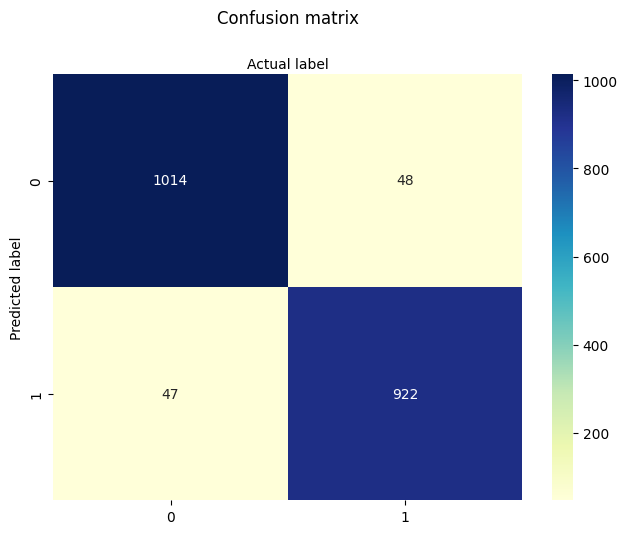

In [90]:
# import the metrics class
from sklearn import metrics
cnf_matrix = metrics.confusion_matrix(y_pred, y_test)
cnf_matrix
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Predicted label')
plt.xlabel('Actual label');

In [91]:
import warnings
warnings.filterwarnings("ignore")
s_new = "csgfnfwbktrssggpwoeksu"
x_new =[c1(s_new[0]),c2(s_new[1]),c3(s_new[2]),c4(s_new[3]),c5(s_new[4]),c6(s_new[5]),c7(s_new[6]),c8(s_new[7]),c9(s_new[8]),c10(s_new[9]),c11(s_new[10]),
           c12(s_new[11]),c13(s_new[12]),c14(s_new[13]),c15(s_new[14]),c16(s_new[15]),c17(s_new[16]),c18(s_new[17]),c19(s_new[18]),c20(s_new[19]),c21(s_new[20]),c22(s_new[21]) ]
#print(x_new)
y_new = logreg.predict(np.array(x_new).reshape(1, -1))  # 1 sample, all features
if y_new < 1 :
    print("New mushroom classified as EDIBLE")
else:
    print("New mushroom classified as POISONIOUS")
    

New mushroom classified as EDIBLE


Logistic Regression Values
Intercept: 16.338245638061593
Feature Coefficients: 
 [[-0.10679196  1.0858779   0.08770085 -3.45164693  0.1401467   0.15454476
  -8.99778707  7.76721394 -0.11239972 -0.05623177 -2.0372923  -0.70146004
  -0.05240369 -0.30982138  0.3404571   0.13064143  0.20039935 -0.76786521
  -0.85611156  0.46649308 -0.59358004 -0.19686631]]
New mushroom classified as EDIBLE


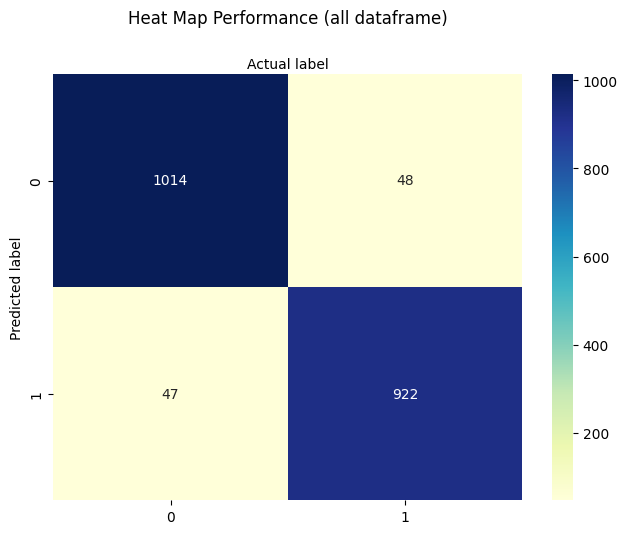

In [92]:
# 7.6.1 Improved code (using OpenAI assisted refactoring)
##########################################################################################################################
##### Encoding definitions: (ordered list of categories, starting index for ordinal encoding)#############################
##########################################################################################################################
encodings = {
    'poison-class':               (['e', 'p'], 0),
    'cap-shape':                  (['b','c','x','f','k','s'], 1),
    'cap-surface':                (['f','g','y','s'], 1),
    'cap-color':                  (['n','b','c','g','r','p','u','e','w','y'], 1),
    'bruises':                    (['f','t'], 1),
    'odor':                       (['a','l','c','y','f','m','n','p','s'], 0),
    'gill-attachment':            (['a','d','f','n'], 1),
    'gill-spacing':              (['c','w','d'], 1),
    'gill-size':                 (['b','n'], 1),
    'gill-color':                (['k','n','b','h','g','r','o','p','u','e','w','y'], 1),
    'stalk-shape':              (['e','t'], 1),
    'stalk-root':               (['b','c','u','e','z','r','?'], 1),
    'stalk-surface-above-ring':(['f','y','k','s','?'], 1),
    'stalk-surface-below-ring':(['f','y','k','s','?'], 1),
    'stalk-color-above-ring':  (['n','b','c','g','o','p','e','w','y'], 1),
    'stalk-color-below-ring':  (['n','b','c','g','o','p','e','w','y'], 1),
    'veil-type':               (['p','u'], 1),
    'veil-color':              (['n','o','w','y'], 1),
    'ring-number':             (['n','o','t'], 1),
    'ring-type':               (['c','e','f','l','n','p','s','z'], 1),
    'spore-print-color':       (['k','n','b','h','r','o','u','w','y','?'], 1),
    'population':              (['a','c','n','s','v','y','?'], 1),
    'habitat':                 (['g','l','m','p','u','w','d'], 1)
}
##########################################################################################################################
###### Define Encoder Generator ##########################################################################################
##########################################################################################################################
def make_encoder(alphabet, offset=1, name='feature'):
    def encoder(val):
        if val in alphabet:
            return alphabet.index(val) + offset
        raise Exception(f"Encoding failed in '{name}': unknown value '{val}'")
    return encoder
##########################################################################################################################
##### Apply Encodings ####################################################################################################
##########################################################################################################################
from pandas import get_dummies

def apply_encodings(df, encodings, method="ordinal"):
    encoded_df = pd.DataFrame(index=df.index)
    for col, (alphabet, offset) in encodings.items():
        if method == "ordinal":
            encoder = make_encoder(alphabet, offset=offset, name=col)
            encoded_df[col] = df[col].apply(encoder)
        elif method == "onehot":
            df[col] = pd.Categorical(df[col], categories=alphabet, ordered=True)
            dummies = get_dummies(df[col], prefix=col)
            encoded_df = pd.concat([encoded_df, dummies], axis=1)
        else:
            raise ValueError("Unknown encoding method: use 'ordinal' or 'onehot'")
    return encoded_df
##########################################################################################################################
##### Report Generator ###################################################################################################
##########################################################################################################################
def generate_encoding_markdown(encodings):
    md = "# Mushroom Feature Encoding Reference\n\n"
    for feature, (alphabet, offset) in encodings.items():
        md += f"### {feature}\n"
        md += "| Category | Encoded Value |\n"
        md += "|----------|----------------|\n"
        for i, symbol in enumerate(alphabet):
            md += f"| `{symbol}` | `{i + offset}` |\n"
        md += "\n"
    return md

#########################################################################################################################
###### Step 1: Load the raw data ########################################################################################
#########################################################################################################################
###### Get the database (unchanged from original code)
import sys # Module to process commands to/from the OS using a shell-type syntax
import requests
remote_url="http://54.243.252.9/ce-5319-webroot/ce5319jb/lessons/logisticregression/agaricus-lepiota.data"  # set the url
rget = requests.get(remote_url, allow_redirects=True)  # get the remote resource, follow imbedded links
localfile = open('poisonmushroom.csv','wb') # open connection to a local file same name as remote
localfile.write(rget.content) # extract from the remote the contents,insert into the local file same name
localfile.close() # close connection to the local file
###### Read and load data into dataframe, set column names to the encoding keys
mymushroom = pd.read_csv('poisonmushroom.csv', header=None)
mymushroom.columns = list(encodings.keys())
#########################################################################################################################
###### Step 2: Encode ###################################################################################################
#########################################################################################################################
interim = apply_encodings(mymushroom.copy(), encodings, method="ordinal")  # or "onehot"
#########################################################################################################################
###### Step 3: Export Markdown (optional) ###############################################################################
#########################################################################################################################
md_report = generate_encoding_markdown(encodings)
with open("encoding_reference.md", "w") as f:
    f.write(md_report)
interim.head()
#########################################################################################################################
###### Step 4: Split Dataframe for Training, Testing  ###################################################################
#########################################################################################################################
feature_cols = mymushroom.columns[1:] #split dataset in features and target variable
X = interim[feature_cols] # Features
y = interim['poison-class'] # Target variable
# split X and y into training and testing sets
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=0)
#########################################################################################################################
###### Step 5: Load Logistic Regression, Fit Data Model  ################################################################
#########################################################################################################################
from sklearn.linear_model import LogisticRegression # import the method
logreg = LogisticRegression(max_iter=1000) # instantiate the model (using the default parameters)
logreg.fit(X_train,y_train) # fit the model with data
y_pred=logreg.predict(X_test) # predict the test set
#########################################################################################################################
###### Step 6: Report Results  ##########################################################################################
#########################################################################################################################
print("Logistic Regression Values")
print("Intercept:", logreg.intercept_[0])
print("Feature Coefficients: \n",logreg.coef_)
from sklearn import metrics # import the metrics class
cnf_matrix = metrics.confusion_matrix(y_pred, y_test)
cnf_matrix
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g') # create heatmap
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Heat Map Performance (all dataframe)', y=1.1)
plt.ylabel('Predicted label')
plt.xlabel('Actual label');
#########################################################################################################################
###### Step 7: Classify New Mushroom  ###################################################################################
#########################################################################################################################
s_new = "csgfnfwbktrssggpwoeksu" # Sample input string from a new mushroom (22 characters)
# Create encoders from the original encoding dictionary
encoders = {
    col: make_encoder(alphabet, offset=offset, name=col)
    for col, (alphabet, offset) in encodings.items()
}
# Get list of feature columns (excluding 'poison-class')
feature_cols = list(encodings.keys())[1:]  # skip target
# Zip characters with corresponding features
try:
    x_new = [encoders[col](char) for col, char in zip(feature_cols, s_new)]
except Exception as e:
    print("Encoding error:", e)
    x_new = None
# Predict if encoding successful
if x_new:
    y_new = logreg.predict(np.array(x_new).reshape(1, -1))  # reshape for sklearn
if y_new < 1:
    print("\033[92mNew mushroom classified as EDIBLE\033[0m")      # Green text
else:
    print("\033[91mNew mushroom classified as POISONOUS\033[0m")   # Red text

In [93]:
%reset -f
# build a dataset -  
import numpy as np
from numpy.random import normal
import math

M = 10_000
x = np.hstack([
    normal(0.0, 1.0, M).reshape(M, 1),
    normal(0.0, 1.0, M).reshape(M, 1),
    normal(0.0, 1.0, M).reshape(M, 1)
])
z = np.dot(x, np.array([0.15, 0.5, 0.2])) + 2.0 + normal(0.0, 0.01, M)
y = np.exp(z)

X    = x  # Design Matrix
Yobs = [math.trunc(item) for item in y]  # Discrete Target vector 

print(X[2][0])
print(x[2][0])
print(Yobs[0])

-0.3082091962166388
-0.3082091962166388
3


In [94]:
Yobs[1]

8

In [95]:
x[0:12]

array([[-1.04196896, -0.85124958, -0.89414553],
       [-0.32694623,  0.02530301,  0.69814781],
       [-0.3082092 ,  0.14995534, -0.79696863],
       [ 0.82711746,  0.50262614,  0.26527505],
       [ 1.07078142,  1.19763325,  1.31284919],
       [-3.05557742,  0.343873  ,  1.75246224],
       [ 1.00593193,  0.83969649,  1.2195609 ],
       [-1.76505643, -0.91064384,  0.6334922 ],
       [ 0.61171791, -1.11284845, -1.06640961],
       [ 2.00335928,  1.21496645,  1.08589271],
       [-0.02941931, -0.15019781,  0.43973858],
       [-1.58293956, -0.90016974, -0.78833107]])

In [96]:
X[0:12]

array([[-1.04196896, -0.85124958, -0.89414553],
       [-0.32694623,  0.02530301,  0.69814781],
       [-0.3082092 ,  0.14995534, -0.79696863],
       [ 0.82711746,  0.50262614,  0.26527505],
       [ 1.07078142,  1.19763325,  1.31284919],
       [-3.05557742,  0.343873  ,  1.75246224],
       [ 1.00593193,  0.83969649,  1.2195609 ],
       [-1.76505643, -0.91064384,  0.6334922 ],
       [ 0.61171791, -1.11284845, -1.06640961],
       [ 2.00335928,  1.21496645,  1.08589271],
       [-0.02941931, -0.15019781,  0.43973858],
       [-1.58293956, -0.90016974, -0.78833107]])

In [97]:
def mu(b0,b1,b2,b3,x,y,z): #poisson function (scalar) 3-design columns
    import math
    mu = math.exp(b0+b1*x+b2*y+b3*z)
    return(mu)

def sse(mod,obs): #compute sse from observations and model values
    howmany = len(mod)
    sse=0.0
    for i in range(howmany):
        sse=sse+(mod[i]-obs[i])**2
    return(sse)

def merit(beta): # merit function to minimize
    global Yobs,X #access lists already defined external to function
    mod=[0 for i in range(len(X))]
    for i in range(len(X)):
        mod[i]=mu(beta[0],beta[1],beta[2],beta[3],X[i][0],X[i][1],X[i][2])
    merit = sse(mod,Yobs)
    return(merit)

In [98]:
beta = [0,0,0,0] #initial guess of betas
merit(beta) #check that does not raise an exception

781238.0

In [99]:
import numpy as np
from scipy.optimize import minimize

#x0 = np.array([-3.0597,0.1615])
x0 = np.array(beta)
res = minimize(merit, x0, method='powell',options={'disp': True , 'maxiter':10 , 'return_all' : True})

Optimization terminated successfully.
         Current function value: 1035.440719
         Iterations: 5
         Function evaluations: 234


In [100]:
res.x

array([1.92859994, 0.15732782, 0.52267212, 0.20893387])

In [101]:
res.fun

array(1035.44071886)

In [102]:
mu(1.92859994, 0.15732782, 0.52267212, 0.20893387,-1.03262907e+00,  1.99696197e-01, -1.33509785e+00)

4.911439782570921

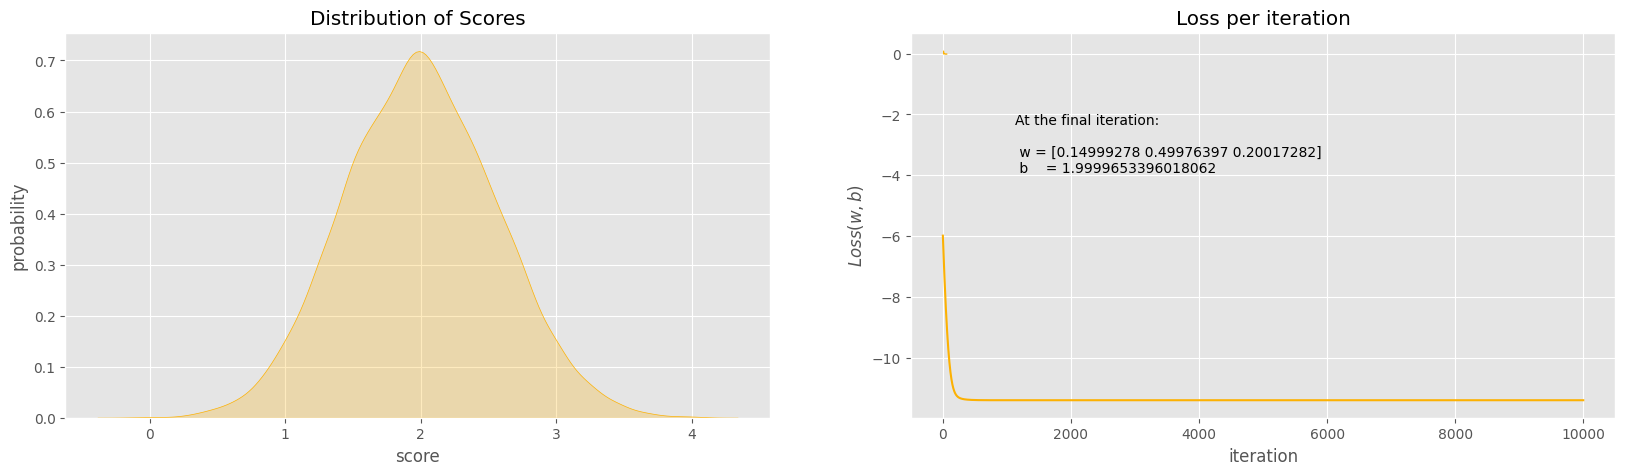

The final values for w = [0.14999278 0.49976397 0.20017282]
The final value for b = 1.9999653396018062


In [103]:
%reset -f
# source code adapted from https://github.com/ximenasandoval/
#                          Poisson_regression/blob/main/
#                          Poisson%20regression%20model.ipynb

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.random import normal
plt.rcParams['figure.figsize'] = (16,8)
plt.style.use('ggplot')



np.random.seed(37)
sns.color_palette("Set2", as_cmap=True)

M = 10_000
x = np.hstack([
    normal(0.0, 1.0, M).reshape(M, 1),
    normal(0.0, 1.0, M).reshape(M, 1),
    normal(0.0, 1.0, M).reshape(M, 1)
])
z = np.dot(x, np.array([0.15, 0.5, 0.2])) + 2.0 + normal(0.0, 0.01, M)
y = np.exp(z)



fig, ax = plt.subplots(1, 2, figsize=(20, 5))

sns.kdeplot(z, ax=ax[0], color='#fcb103', fill=True)
ax[0].set_title(r'Distribution of Scores')
ax[0].set_xlabel('score')
ax[0].set_ylabel('probability')

sns.kdeplot(y, ax=ax[1], color='#fcb103', fill=True)
ax[1].set_title(r'Distribution of Means')
ax[1].set_xlabel('mean')
ax[1].set_ylabel('probability')

def loss(x, y, w, b):
    y_hat = np.exp(x @ w + b)
    # You can use the normal MSE error too! 
    #error = np.square(y_hat - y).mean() / 2
    error = (y_hat - np.log(y_hat) * y).mean()
    return error
        
def grad(x, y, w, b):
    M, n = x.shape
    y_hat = np.exp(x @ w + b)
    dw = (x.T @ (y_hat - y)) / M
    db = (y_hat - y).mean()
    return dw, db

def gradient_descent(x, y, w_0, b_0, alpha, num_iter):
    w, b = w_0.copy(), b_0
    hist = np.zeros(num_iter)
    M, n = x.shape
    
    for iter in range(num_iter):
        dw, db = grad(x, y, w, b)
        w -= alpha * dw 
        b -= alpha * db
        hist[iter] = loss(x, y, w, b)

    return w, b, hist


M, n = x.shape
w_0 = np.zeros((n, ))
b_0 = 1
alpha = 0.001
w, b, hist = gradient_descent(x, y, w_0, b_0, alpha, num_iter=10_000)




plt.plot(hist, 'b', color='#fcb103')
plt.title(u'Loss per iteration')
plt.xlabel(u'iteration')
plt.ylabel(r'$Loss(w, b)$')
plt.figtext(x=.6, y=.6, s="At the final iteration:\n\n w = {}\n b    = {}".format(w, b))
plt.show()



print(f"The final values for w = {w}")
print(f"The final value for b = {b}")



In [104]:
%reset -f
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Simulate dataset
np.random.seed(42)
n = 100
Pipe_Age = np.random.uniform(0, 10, n)
Urban = np.random.binomial(1, 0.5, n)
X = sm.add_constant(pd.DataFrame({'Pipe_Age': Pipe_Age, 'Urban': Urban}))

beta_true = np.array([0.5, 0.2, 0.8])  # intercept, age effect, urban effect
mu = np.exp(X @ beta_true)
Incidents = np.random.poisson(mu)

df_sim = pd.DataFrame({'Pipe_Age': Pipe_Age, 'Urban': Urban, 'Incidents': Incidents})

In [105]:
X.describe()

,const,Pipe_Age,Urban
count,100.0,100.000000,100.000000
mean,1.0,4.701807,0.510000
std,0.0,2.974894,0.502418
min,1.0,0.055221,0.000000
25%,1.0,1.932008,0.000000
50%,1.0,4.641425,1.000000
75%,1.0,7.302031,1.000000
max,1.0,9.868869,1.000000


In [106]:
# Fit and summarize Poisson model
poisson_model = sm.GLM(df_sim.Incidents, X, family=sm.families.Poisson()).fit()
print(poisson_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              Incidents   No. Observations:                  100
Model:                            GLM   Df Residuals:                       97
Model Family:                 Poisson   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -233.32
Date:                Fri, 11 Jul 2025   Deviance:                       107.99
Time:                        16:58:05   Pearson chi2:                     103.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.9805
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4602      0.104      4.404      0.0

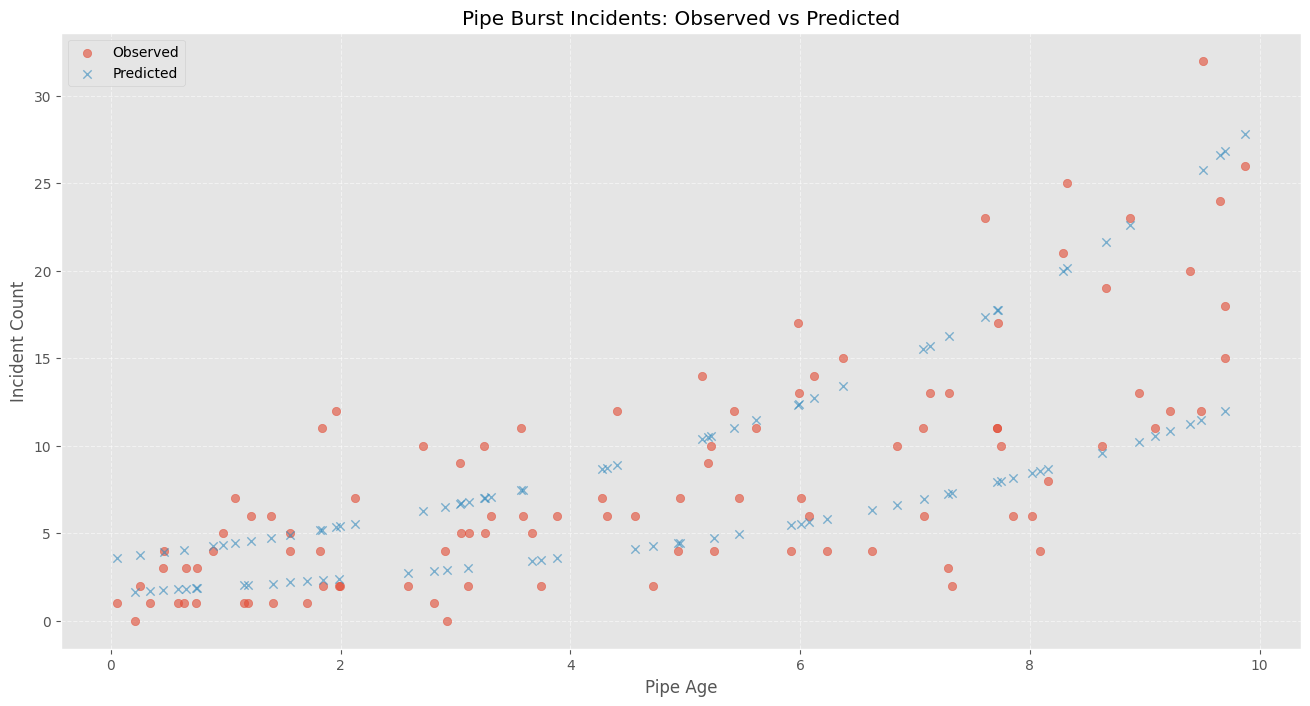

In [107]:
# Plot observed vs predicted
df_sim['Predicted'] = poisson_model.predict(X)
plt.scatter(df_sim.Pipe_Age, df_sim.Incidents, label='Observed', alpha=0.6)
plt.scatter(df_sim.Pipe_Age, df_sim.Predicted, marker='x', label='Predicted', linewidth=1, alpha=0.6)
plt.xlabel('Pipe Age')
plt.ylabel('Incident Count')
plt.legend()
plt.title('Pipe Burst Incidents: Observed vs Predicted')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [108]:
%reset -f
import os
import requests
import zipfile
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Load dataset from UCI repo (daily counts)
url = "https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip"
filename = "bsd.zip"
csvname = "day.csv"
# Fallback: local copy if download fails
if not os.path.exists(filename):
    try:
        response = requests.get(url, timeout=60)
        with open(filename, 'wb') as f:
            f.write(response.content)
        print(f"Dataset downloaded and saved as '{filename}'")
    except Exception as e:
        print(f"Could not download file. Please ensure '{filename}' is available locally.\n", e)


In [109]:

# Unzip the archive if not already unzipped
if not os.path.exists(csvname):
    try:
        with zipfile.ZipFile(filename, 'r') as zip_ref:
            zip_ref.extractall()
        print(f"Extracted '{csvname}' from archive.")
    except Exception as e:
        print("Error extracting ZIP file:", e)

In [110]:
# Load the daily bike rental data
df = pd.read_csv(csvname)
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


                 Generalized Linear Model Regression Results                  
Dep. Variable:                    cnt   No. Observations:                  731
Model:                            GLM   Df Residuals:                      726
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -2.0111e+05
Date:                Fri, 11 Jul 2025   Deviance:                   3.9482e+05
Time:                        16:58:14   Pearson chi2:                 3.83e+05
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.9579      0.003   2588.870      0.0

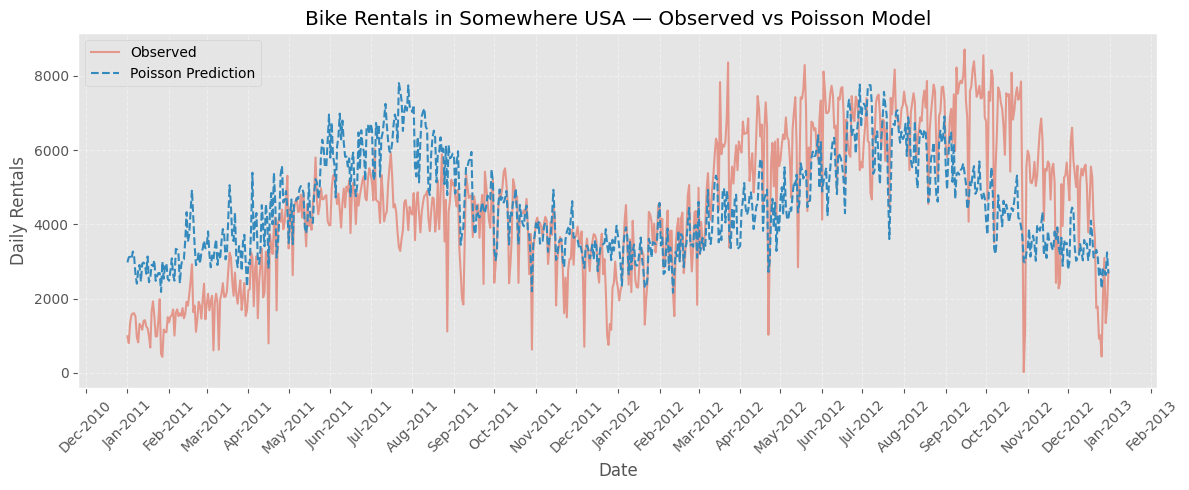

In [111]:
# Variables:
# dteday: date
# temp: normalized temperature
# hum: humidity
# weathersit: weather condition
# workingday: 1 if working day, 0 otherwise
# cnt: count of total rentals

# Create copy and select relevant columns
df_small = df[['dteday', 'cnt', 'temp', 'hum', 'workingday', 'weathersit']].copy()
df_small['const'] = 1  # manually add intercept

# Fit Poisson model
X = df_small[['const', 'temp', 'hum', 'workingday', 'weathersit']]
y = df_small['cnt']

poisson_model = sm.GLM(y, X, family=sm.families.Poisson()).fit()
# Later: Assign predicted values safely

print(poisson_model.summary())

import matplotlib.dates as mdates

df_small['Predicted'] = poisson_model.predict(X)

# Ensure dteday is datetime type
df_small['dteday'] = pd.to_datetime(df_small['dteday'])

plt.figure(figsize=(12, 5))
plt.plot(df_small['dteday'], df_small['cnt'], label='Observed', alpha=0.5)
plt.plot(df_small['dteday'], df_small['Predicted'], '--', label='Poisson Prediction')

# Set monthly ticks
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))  # Every month
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))  # Format as Jan-2011

plt.xlabel('Date')
plt.ylabel('Daily Rentals')
plt.title('Bike Rentals in Somewhere USA — Observed vs Poisson Model')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()


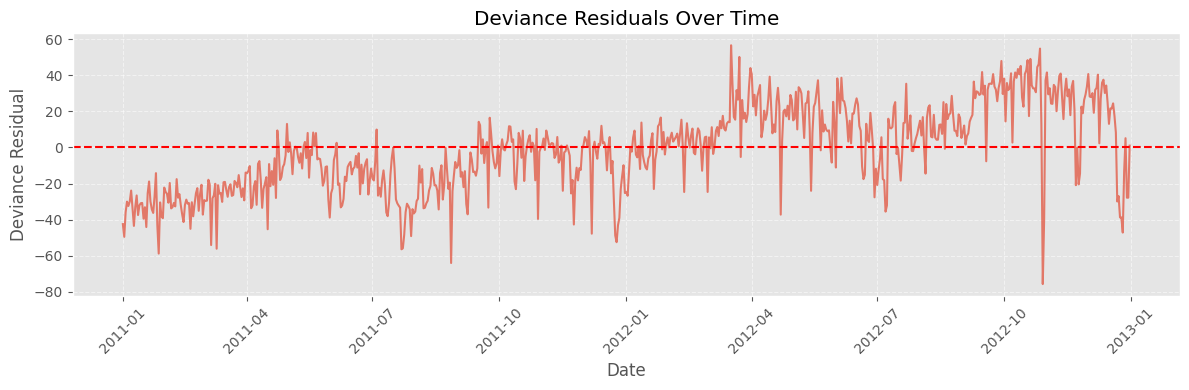

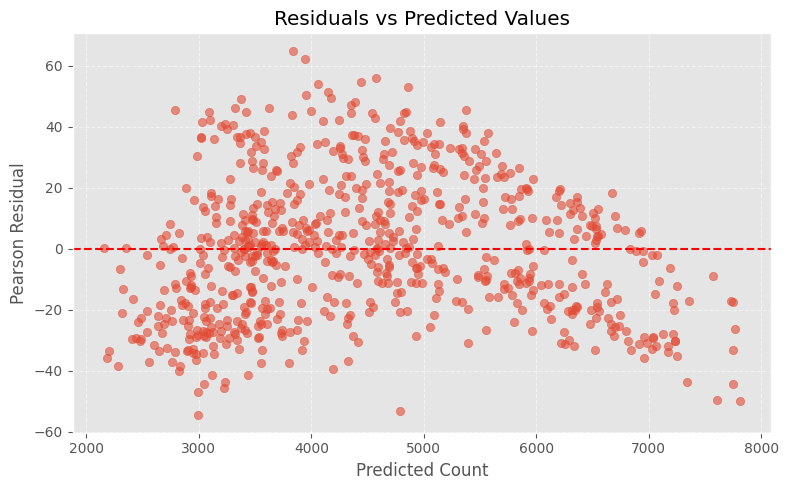

In [112]:
import numpy as np

# Calculate residuals
mu = df_small['Predicted']
y = df_small['cnt']

# Deviance residuals
deviance_resid = np.sign(y - mu) * np.sqrt(2 * (y * np.log((y + 1e-8) / mu) - (y - mu)))

# Pearson residuals
pearson_resid = (y - mu) / np.sqrt(mu)

# Add to DataFrame
df_small['Deviance_Resid'] = deviance_resid
df_small['Pearson_Resid'] = pearson_resid

# Plot: Deviance residuals over time
plt.figure(figsize=(12, 4))
plt.plot(df_small['dteday'], df_small['Deviance_Resid'], alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.title('Deviance Residuals Over Time')
plt.xlabel('Date')
plt.ylabel('Deviance Residual')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Plot: Residuals vs Predicted
plt.figure(figsize=(8, 5))
plt.scatter(mu, pearson_resid, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Count')
plt.ylabel('Pearson Residual')
plt.title('Residuals vs Predicted Values')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
